# Mobile Network Traffic Forecasting
## Comparative Time Series Analysis: Milan, Italy (Nov-Dec 2013)

This notebook works on a complete pipeline for analysing and forecasting
mobile network traffic data from the city of Milan. The analysis is divided
into three tasks:
- **Task 1:** Data Handling and Memory Management
- **Task 2:** Exploratory Data Analysis
- **Task 3:** Forecasting Models (ARIMA, LSTM, GRU)

### How to Run
1. Run the startup cell below first at the beginning of every session
2. It mounts Google Drive, imports all libraries, and loads the processed data
3. All subsequent cells can then be run in order


Dataset: Telecom Italia Big Data Challenge City of Milan


### **Hardware and Software:**

**Platform**: Google Colab

**RAM:** 12.67GB

**GPU:** T4

**Python:** 3.12

**Key libraries:** Pandas, numpy, torch, statsmodels, scikit-learn






# **Task 1: Data Handling and Memory Management**

The dataset consists of 61 daily `.txt` files totalling approximately 5GB.
Loading this data anyhow would exceed available RAM. This section shows how I was able to efficiently load, process, and store the dataset.

**Key optimisation strategies:**
- Loading files one at a time using a loop to avoid memory overflow
- Retaining only 3 of the 8 columns (Square ID, Time Interval, Internet Traffic)
- Downcasting data types from default int64/float64 to int16/float32
- Aggregating multiple rows per square per time interval into a single value
- Saving the processed data as a compressed Parquet file for fast reloading

In [36]:
import pandas as pd
import numpy as np
import os
import glob
import gc
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("All libraries imported successfully!")

All libraries imported successfully!


In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
nov_path = "/content/drive/MyDrive/milan-traffic/november/dataverse_files"
dec_path = "/content/drive/MyDrive/milan-traffic/december/dataverse_files (1)"

nov_files = sorted(glob.glob(os.path.join(nov_path, "*.txt")))
dec_files = sorted(glob.glob(os.path.join(dec_path, "*.txt")))

print(f"November files found: {len(nov_files)}")
print(f"December files found: {len(dec_files)}")

print("\nFirst 3 November files:")
for f in nov_files[:3]:
  print(f" - {os.path.basename(f)}")

print("\nFirst 3 December files:")
for f in dec_files[:3]:
  print(f" - {os.path.basename(f)}")


November files found: 30
December files found: 31

First 3 November files:
 - sms-call-internet-mi-2013-11-01.txt
 - sms-call-internet-mi-2013-11-02.txt
 - sms-call-internet-mi-2013-11-03.txt

First 3 December files:
 - sms-call-internet-mi-2013-12-01.txt
 - sms-call-internet-mi-2013-12-02.txt
 - sms-call-internet-mi-2013-12-03.txt


## 1.1 Initial Data Exploration

Before loading all 61 files, a single file is loaded to inspect the raw
data structure. This allows us to identify which columns are needed and
what data types are used by default, forming the basis for our optimisation
strategy.

Memory usage is recorded before loading to establish a baseline for
comparison after optimisation.

In [39]:
#Memory before loading any data
ram = psutil.virtual_memory()
memory_before = ram.used / 1024**2 # Changes the unit of measuremnet to MB

print(f"Memory usage before loading: {memory_before:.2f} MB")
print(f"Total RAM available: {ram.total / 1024**3:.2f} GB")

#Load just One file to see what the data looks like
sample_file = nov_files[0]

df_sample = pd.read_csv(sample_file, sep="\t", header=None)

print(f"\nFirst 5 rows:")
print(df_sample.head())
print(f"\nShape: {df_sample.dtypes}")

Memory usage before loading: 7418.79 MB
Total RAM available: 12.67 GB

First 5 rows:
   0              1   2         3         4         5         6          7
0  1  1383260400000   0  0.081363       NaN       NaN       NaN        NaN
1  1  1383260400000  39  0.141864  0.156787  0.160938  0.052275  11.028366
2  1  1383261000000   0  0.136588       NaN       NaN  0.027300        NaN
3  1  1383261000000  33       NaN       NaN       NaN       NaN   0.026137
4  1  1383261000000  39  0.278452  0.119926  0.188777  0.133637  11.100963

Shape: 0      int64
1      int64
2      int64
3    float64
4    float64
5    float64
6    float64
7    float64
dtype: object


## 1.2 Optimised Data Loading

All 61 files are loaded one at a time using a loop. For each file:
1. Only columns 0 (Square ID), 1 (Time Interval), and 7 (Internet Traffic) are loaded
2. Data types are downcast: Square ID → int16, Traffic → float32
3. Time is converted from milliseconds to datetime format
4. Missing traffic values are filled with 0 (no activity = zero traffic)
5. Rows are aggregated by square and time to combine country-level records
6. Each processed file is appended to a list and memory is freed immediately

**Why process one file at a time?**
Loading all 61 files simultaneously would require approximately 19GB of RAM
which exceeds the available 12.67GB on Google Colab. Processing sequentially
keeps peak memory usage manageable.

In [40]:
all_files = nov_files + dec_files
print(f"Total files to load: {len(all_files)}")

result = []

for i, file in enumerate(all_files):
    df_temp = pd.read_csv(
      file,
      sep="\t",
      header=None,
      usecols=[0, 1, 7],
      dtype={0: np.int16,
             1: np.int64,
             7: np.float32}
    )

    df_temp.columns = ["square_id", "time_interval", "internet_traffic"]

    #convert time from milliseconds to datetime
    df_temp["time_interval"] = pd.to_datetime(df_temp['time_interval'], unit='ms')

    #fill missing traffic with 0
    df_temp['internet_traffic'] = df_temp['internet_traffic'].fillna(0)


    #aggregates by square and time
    df_temp = df_temp.groupby(
      ['square_id', 'time_interval'],
      as_index=False
    )['internet_traffic'].sum()

    result.append(df_temp)

    del df_temp
    gc.collect()

    print(f"[{i+1}/{len(all_files)}] Loaded: {os.path.basename(file)}")

df_all = pd.concat(result, ignore_index=True)

ram_after = psutil.virtual_memory()
memory_after = ram_after.used / 1024**2

print(f'\n Done')
print(f"Total rows: {len(df_all):,}")
print(f"Shape: {df_all.shape}")
print(f"\nMemory before loading: {memory_before:.2f} MB")
print(f"Memory after loading: {memory_after:.2f} MB")
print(f"Memory use by data: {memory_after - memory_before:.2f} MB")
print(f"Dataframe size: {df_all.memory_usage(deep=True).sum() /1024**2:.2f} MB")

Total files to load: 61
[1/61] Loaded: sms-call-internet-mi-2013-11-01.txt
[2/61] Loaded: sms-call-internet-mi-2013-11-02.txt
[3/61] Loaded: sms-call-internet-mi-2013-11-03.txt
[4/61] Loaded: sms-call-internet-mi-2013-11-04.txt
[5/61] Loaded: sms-call-internet-mi-2013-11-05.txt
[6/61] Loaded: sms-call-internet-mi-2013-11-06.txt
[7/61] Loaded: sms-call-internet-mi-2013-11-07.txt
[8/61] Loaded: sms-call-internet-mi-2013-11-08.txt
[9/61] Loaded: sms-call-internet-mi-2013-11-09.txt
[10/61] Loaded: sms-call-internet-mi-2013-11-10.txt
[11/61] Loaded: sms-call-internet-mi-2013-11-11.txt
[12/61] Loaded: sms-call-internet-mi-2013-11-12.txt
[13/61] Loaded: sms-call-internet-mi-2013-11-13.txt
[14/61] Loaded: sms-call-internet-mi-2013-11-14.txt
[15/61] Loaded: sms-call-internet-mi-2013-11-15.txt
[16/61] Loaded: sms-call-internet-mi-2013-11-16.txt
[17/61] Loaded: sms-call-internet-mi-2013-11-17.txt
[18/61] Loaded: sms-call-internet-mi-2013-11-18.txt
[19/61] Loaded: sms-call-internet-mi-2013-11-19.t

## 1.3 Saving Processed Data

The processed dataframe is saved as a Parquet file to Google Drive.

**Why Parquet instead of CSV?**
- Parquet is a compressed columnar format
- Our 1172MB dataframe compresses to just 388MB (67% reduction)
- Parquet loads significantly faster than CSV on subsequent sessions
- Preserves data types (datetime, int16, float32) automatically

This means future sessions can skip the 7-minute loading process and
reload the clean data in seconds.

In [41]:
# Save to Google Drive so we can reload instantly next time
save_path = "/content/drive/MyDrive/milan-traffic/processed_data.parquet"

df_all.to_parquet(save_path, index=False)

print(f"Data saved to {save_path}")
print(f"File size: {os.path.getsize(save_path) / 1024**2:.2f} MB")

Data saved to /content/drive/MyDrive/milan-traffic/processed_data.parquet
File size: 388.23 MB


## 1.4 Data Verification

The saved Parquet file is reloaded to verify integrity. We confirm:
- Correct shape (87,806,617 rows × 3 columns)
- Correct date range (November 2013 to December 2013)
- All 10,000 unique square IDs present
- No missing values remaining
- Optimised data types preserved

In [42]:
# Test loading the saved file
df_test = pd.read_parquet(save_path)

print("Loaded successfully!")
print(f"Shape: {df_test.shape}")
print(f"\nFirst 5 rows:")
print(df_test.head())
print(f"\nData types:\n{df_test.dtypes}")
print(f"\nDate range:")
print(f"  Start: {df_test['time_interval'].min()}")
print(f"  End: {df_test['time_interval'].max()}")

Loaded successfully!
Shape: (87806617, 3)

First 5 rows:
   square_id       time_interval  internet_traffic
0          1 2013-10-31 23:00:00         11.028366
1          1 2013-10-31 23:10:00         11.127101
2          1 2013-10-31 23:20:00         10.892771
3          1 2013-10-31 23:30:00          8.622424
4          1 2013-10-31 23:40:00          8.009928

Data types:
square_id                    int16
time_interval       datetime64[ns]
internet_traffic           float32
dtype: object

Date range:
  Start: 2013-10-31 23:00:00
  End: 2013-12-31 22:50:00


## **TASK 2**

# **Task 2: Exploratory Data Analysis**

This section performs a comprehensive analysis of the Milan mobile network
traffic dataset. The analysis covers:

1. **Traffic Distribution** — Probability density function across all 10,000 areas
2. **Time Series Analysis** — Temporal patterns for 3 key areas
3. **Stationarity Analysis** — Rolling statistics and ADF test
4. **Decomposition** — Trend, seasonality, and residual components
5. **ACF/PACF Analysis** — Temporal dependencies and autocorrelation
6. **Spatial Analysis** — Heatmap of traffic intensity across the city grid
7. **Anomaly Detection** — Identification of unusual traffic patterns

**Three areas are selected for detailed analysis:**
- Square 5161 — Highest total traffic (city centre)
- Square 4159 — Assignment specified area
- Square 4556 — Assignment specified area

## 2.1 Identifying Key Areas

The three geographical areas for detailed analysis are identified:
- The area with the **highest total traffic** over the two-month period
- The two areas specified in the assignment (Square 4159 and Square 4556)

Total traffic per square is computed by summing all internet activity
over the full November-December period.

In [43]:
#Calculate the total traffic per square over the full 2 months
total_traffic = df_test.groupby('square_id')['internet_traffic'].sum()

#Find the square of the highest total traffic
busiest_square = total_traffic.idxmax()
busiest_traffic = total_traffic.max()

print(f"Busiest square ID: {busiest_square}")
print(f"Total traffic: {busiest_traffic:,.2f}")
print(f"\nSquare 4159 total traffic: {total_traffic[4159]:,.2f}")
print(f"Square 4556 total traffic: {total_traffic[4556]:,.2f}")

#Store our 3 areas for use throughout both task 2 and task 3
areas = [busiest_square, 4159, 4556]
print(f"\nOur 3 areas: {areas}")

Busiest square ID: 5161
Total traffic: 12,682,673.00

Square 4159 total traffic: 2,440,715.00
Square 4556 total traffic: 4,537,460.00

Our 3 areas: [np.int16(5161), 4159, 4556]


## 2.2 Traffic Distribution: Probability Density Function

The probability density function (PDF) shows how total two-month traffic
is distributed across all 10,000 geographical areas.

**What to look for:**
- Shape of the distribution (symmetric vs skewed)
- Spread of values (how diverse is traffic across the city?)
- Position of our 3 key areas relative to the overall distribution

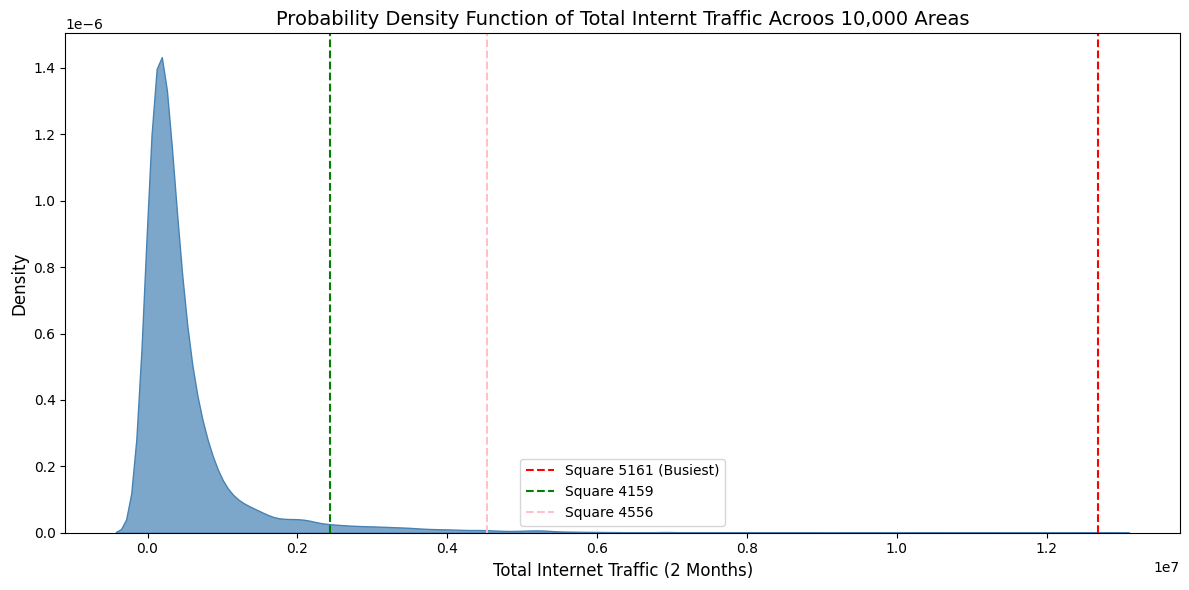


Traffic Statistics:
Mean: 549,972.81
Median: 274,706.19
Std: 886,211.94
Max: 12,682,673.00
Min: 213.63


In [44]:
plt.figure(figsize=(12, 6))

#Plot the distribution
sns.kdeplot(total_traffic, fill=True, color='steelblue', alpha=0.7)


#Add vertical lines for our 3 areas
plt.axvline(total_traffic[busiest_square], color='red',
            linestyle='--', label=f'Square {busiest_square} (Busiest)')
plt.axvline(total_traffic[4159], color='green',
            linestyle='--', label='Square 4159')
plt.axvline(total_traffic[4556], color='pink',
            linestyle='--', label='Square 4556')

plt.title('Probability Density Function of Total Internt Traffic Acroos 10,000 Areas',
          fontsize=14)
plt.xlabel('Total Internet Traffic (2 Months)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan-traffic/pdf_plot.png', dpi=150)
plt.show()

print(f"\nTraffic Statistics:")
print(f"Mean: {total_traffic.mean():,.2f}")
print(f"Median: {total_traffic.median():,.2f}")
print(f"Std: {total_traffic.std():,.2f}")
print(f"Max: {total_traffic.max():,.2f}")
print(f"Min: {total_traffic.min():,.2f}")

## 2.3 Time Series Analysis: First Two Weeks

The temporal dynamics of internet traffic are visualised for the three
selected areas during the first two weeks of November 2013.

**What to look for:**
- Daily cycles (peaks during day, troughs at night)
- Weekly patterns (weekday vs weekend differences)
- Differences in traffic magnitude and variability across areas

Date range in filtered data:
Start: 2013-11-01 00:00:00
End: 2013-11-14 00:00:00


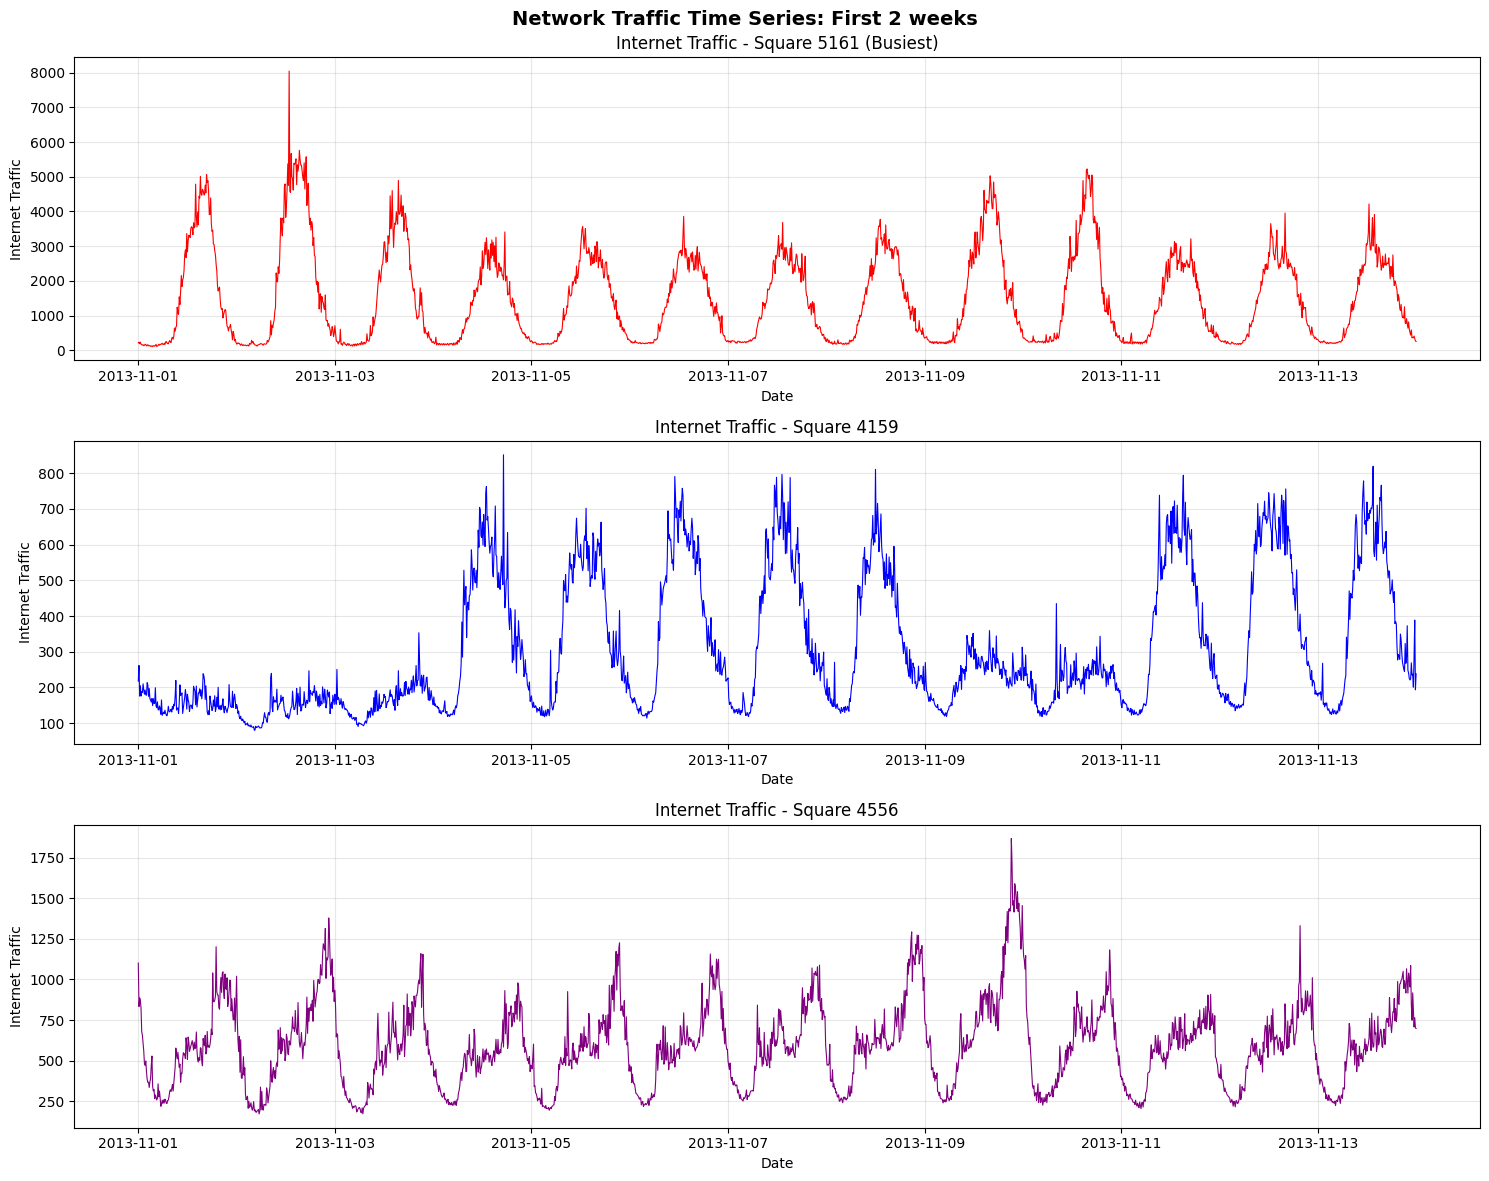

In [45]:
#Filter for the first two weeks only
two_weeks = df_all[
    (df_all['time_interval'] >= '2013-11-01') &
    (df_all['time_interval'] <= '2013-11-14')
].copy()

print(f'Date range in filtered data:')
print(f'Start: {two_weeks['time_interval'].min()}')
print(f'End: {two_weeks['time_interval'].max()}')

#Create a plot with 3 subplots (one for each area)
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

area_labels = [f'Square {busiest_square} (Busiest)', 'Square 4159', 'Square 4556']
colors = ['red', 'blue', 'purple']

for i, (area, label, color) in enumerate(zip(areas, area_labels, colors)):
  area_data = two_weeks[two_weeks['square_id'] == area].copy()
  area_data = area_data.sort_values('time_interval')

  axes[i].plot(area_data['time_interval'],
               area_data['internet_traffic'],
               color=color, linewidth=0.8)
  axes[i].set_title(f'Internet Traffic - {label}', fontsize=12)
  axes[i].set_xlabel('Date', fontsize=10)
  axes[i].set_ylabel('Internet Traffic', fontsize=10)
  axes[i].grid(True, alpha=0.3)


plt.suptitle('Network Traffic Time Series: First 2 weeks',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan-traffic/timeseries_plot.png', dpi=150)
plt.show()


## 2.4 Stationarity Analysis

A time series is stationary if its statistical properties (mean, variance)
remain constant over time. Stationarity is important because:
- ARIMA models require stationary input
- Non-stationary series need differencing before modelling

**Two approaches are used:**
1. **Rolling Statistics**: Visual inspection of rolling mean and standard deviation
2. **Augmented Dickey-Fuller (ADF) Test**:  Statistical test for unit roots

**Null hypothesis:** The series has a unit root (non-stationary)
**If p-value < 0.05:** Reject null hypothesis → series is stationary

Data points: 1464
Date range: 2013-10-31 23:00:00 to 2013-12-31 22:00:00


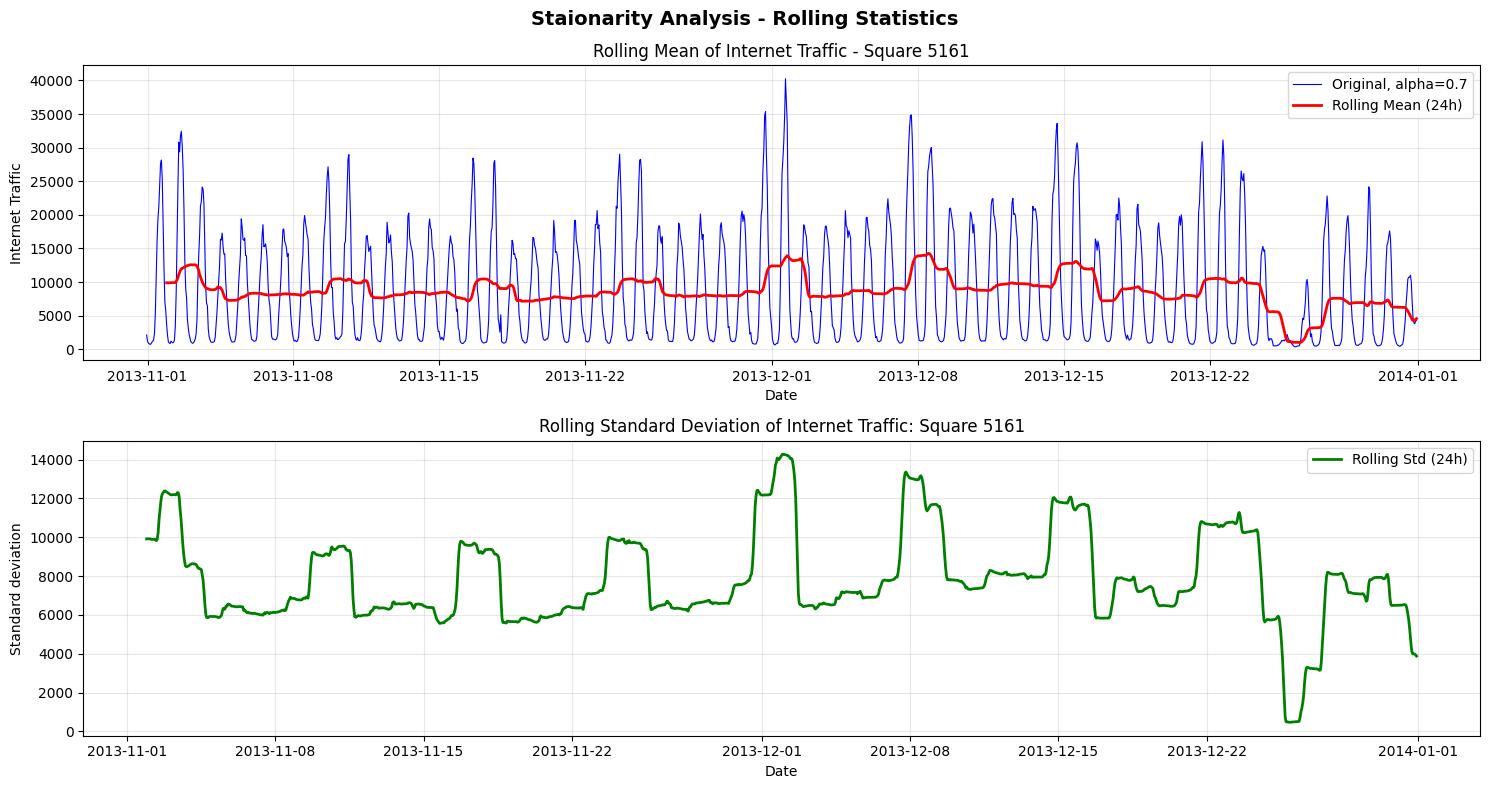


=========== Augmented Dickey-Fuller Test ============
ADF Statistic: -4.4523
p-value: 0.0002
Critical Values:
  1%: -3.4349
  5%: -2.8636
  10%: -2.5678

Result: STATIONARY (p-value < 0.05)
The time series is stationary


In [46]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

#To run stationarity analysis on Square 5161 (busiest)
#Get hourly data for thr full 2 months for square 5161

square_data = df_all[df_all['square_id'] == busiest_square].copy()
square_data = square_data.sort_values('time_interval')
square_data = square_data.set_index('time_interval')

#Resample to hourly to make it cleaner
hourly_data = square_data['internet_traffic'].resample('h').sum()

print(f'Data points: {len(hourly_data)}')
print(f'Date range: {hourly_data.index.min()} to {hourly_data.index.max()}')

#Plot the rolling statistics
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

#Rolling mean and std with 24 hour window
rolling_mean = hourly_data.rolling(window=24).mean()
rolling_std = hourly_data.rolling(window=24).std()

axes[0].plot(hourly_data, color='blue', linewidth=0.8, label='Original, alpha=0.7')
axes[0].plot(rolling_mean, color='red', linewidth=2, label='Rolling Mean (24h)')
axes[0].set_title('Rolling Mean of Internet Traffic - Square 5161', fontsize=12)
axes[0].set_xlabel('Date', fontsize=10)
axes[0].set_ylabel('Internet Traffic', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(rolling_std, color='green', linewidth=2, label='Rolling Std (24h)')
axes[1].set_title('Rolling Standard Deviation of Internet Traffic: Square 5161', fontsize=12)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_ylabel('Standard deviation', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Staionarity Analysis - Rolling Statistics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan-traffic/stationarity_plot.png', dpi=150)
plt.show()

#ADF Test
print('\n=========== Augmented Dickey-Fuller Test ============')
adf_result = adfuller(hourly_data.dropna())
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')
print(f'Critical Values:')
for key, value in adf_result[4].items():
  print(f'  {key}: {value:.4f}')

if adf_result[1] < 0.05:
  print('\nResult: STATIONARY (p-value < 0.05)')
  print('The time series is stationary')
else:
  print('\n Result: NON-STATIONARY (p-value > 0.05)')
  print('The time series is nit stationary')


## 2.5 Stationarity, Decomposition and ACF/PACF: All 3 Areas

The stationarity analysis, time series decomposition, and autocorrelation
analysis are performed for all three areas to enable comparison.

**Key analyses:**
- ADF test results compared across areas
- Decomposition reveals trend, seasonal, and residual components
- ACF/PACF plots inform ARIMA parameter selection for each area


Analysis for Square 5161 (Busiest)
ADF Statistic: -4.4523
p-value: 0.0002
Result: STATIONARY


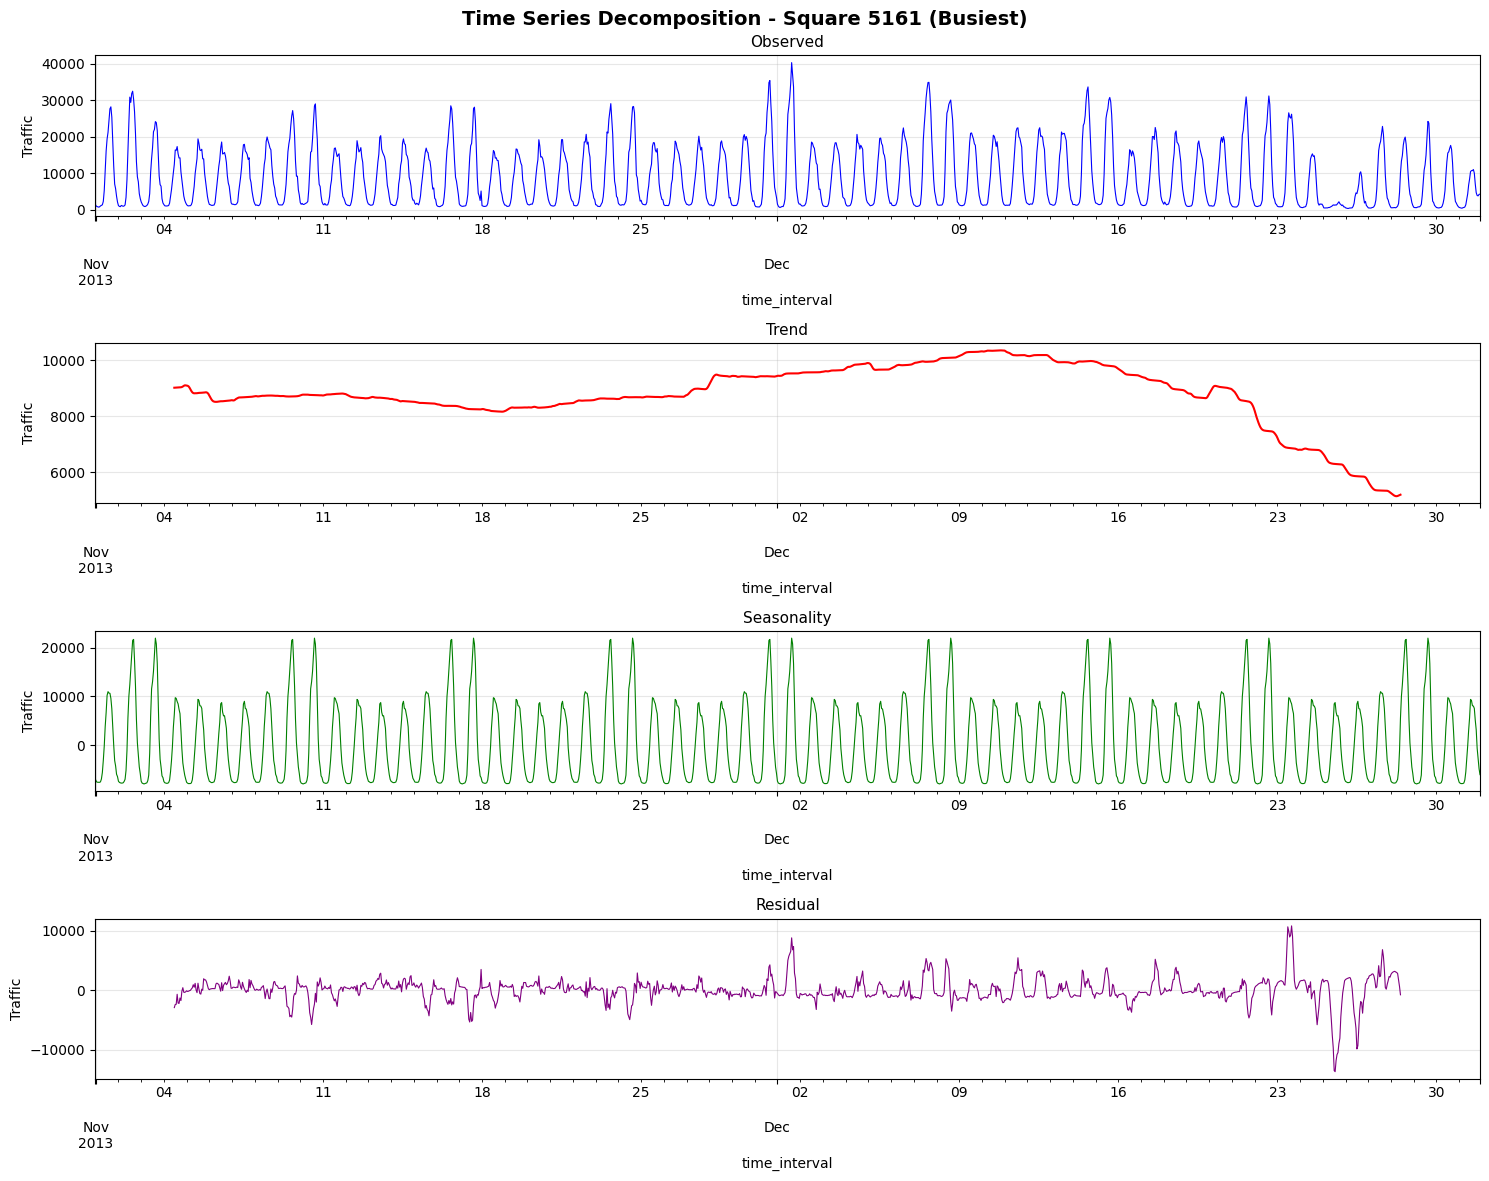

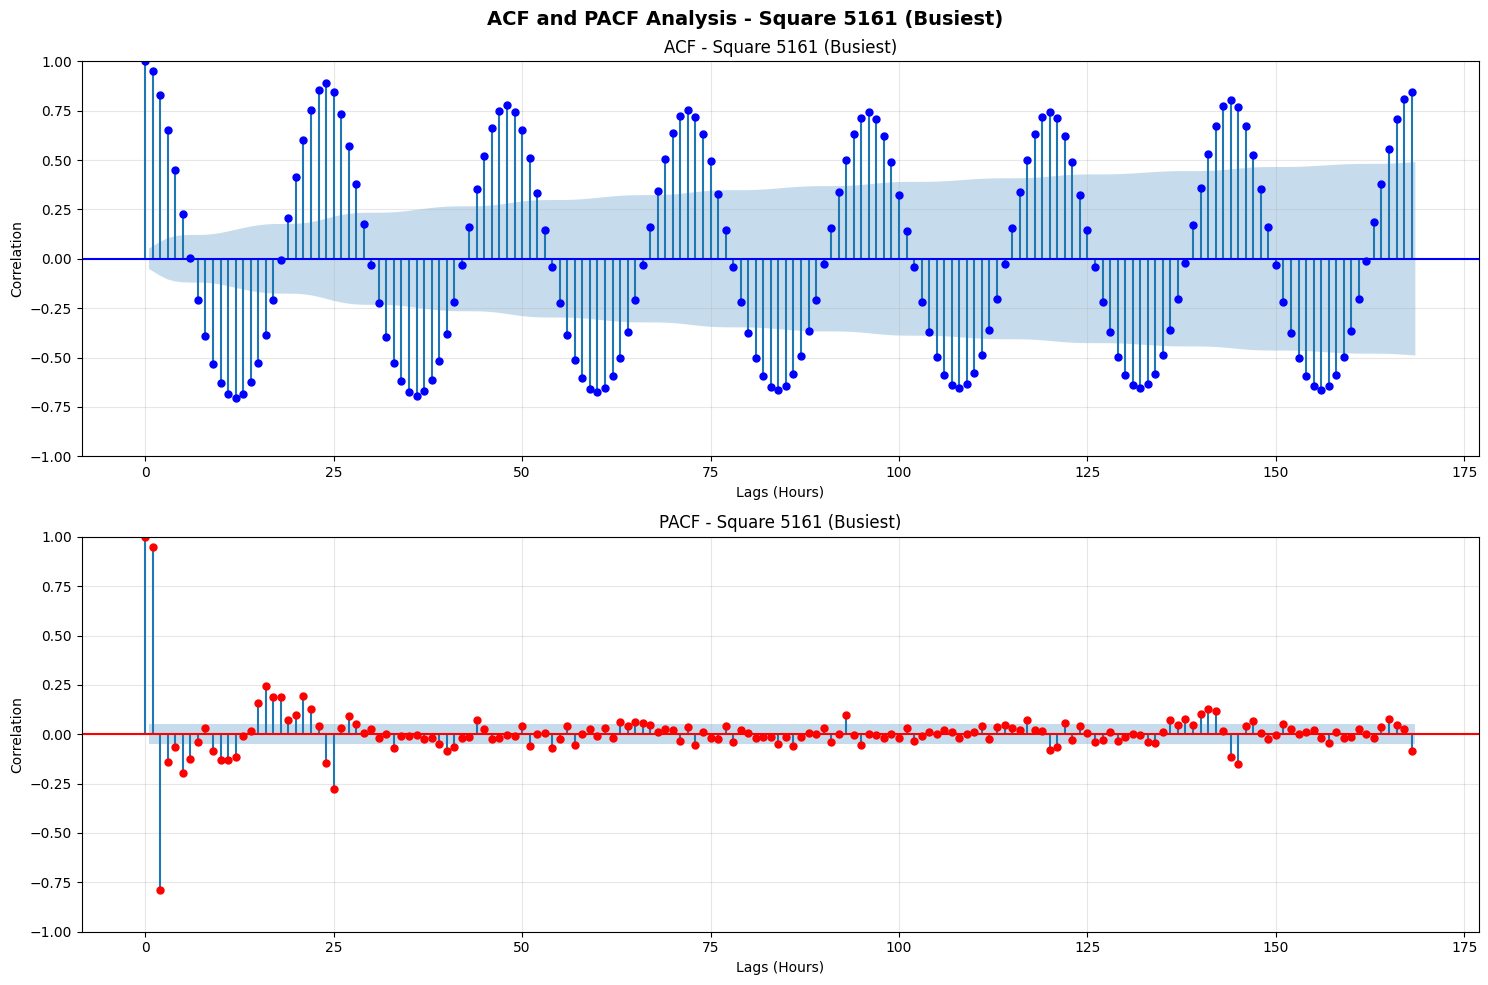


Analysis for Square 4159
ADF Statistic: -3.7917
p-value: 0.0030
Result: STATIONARY


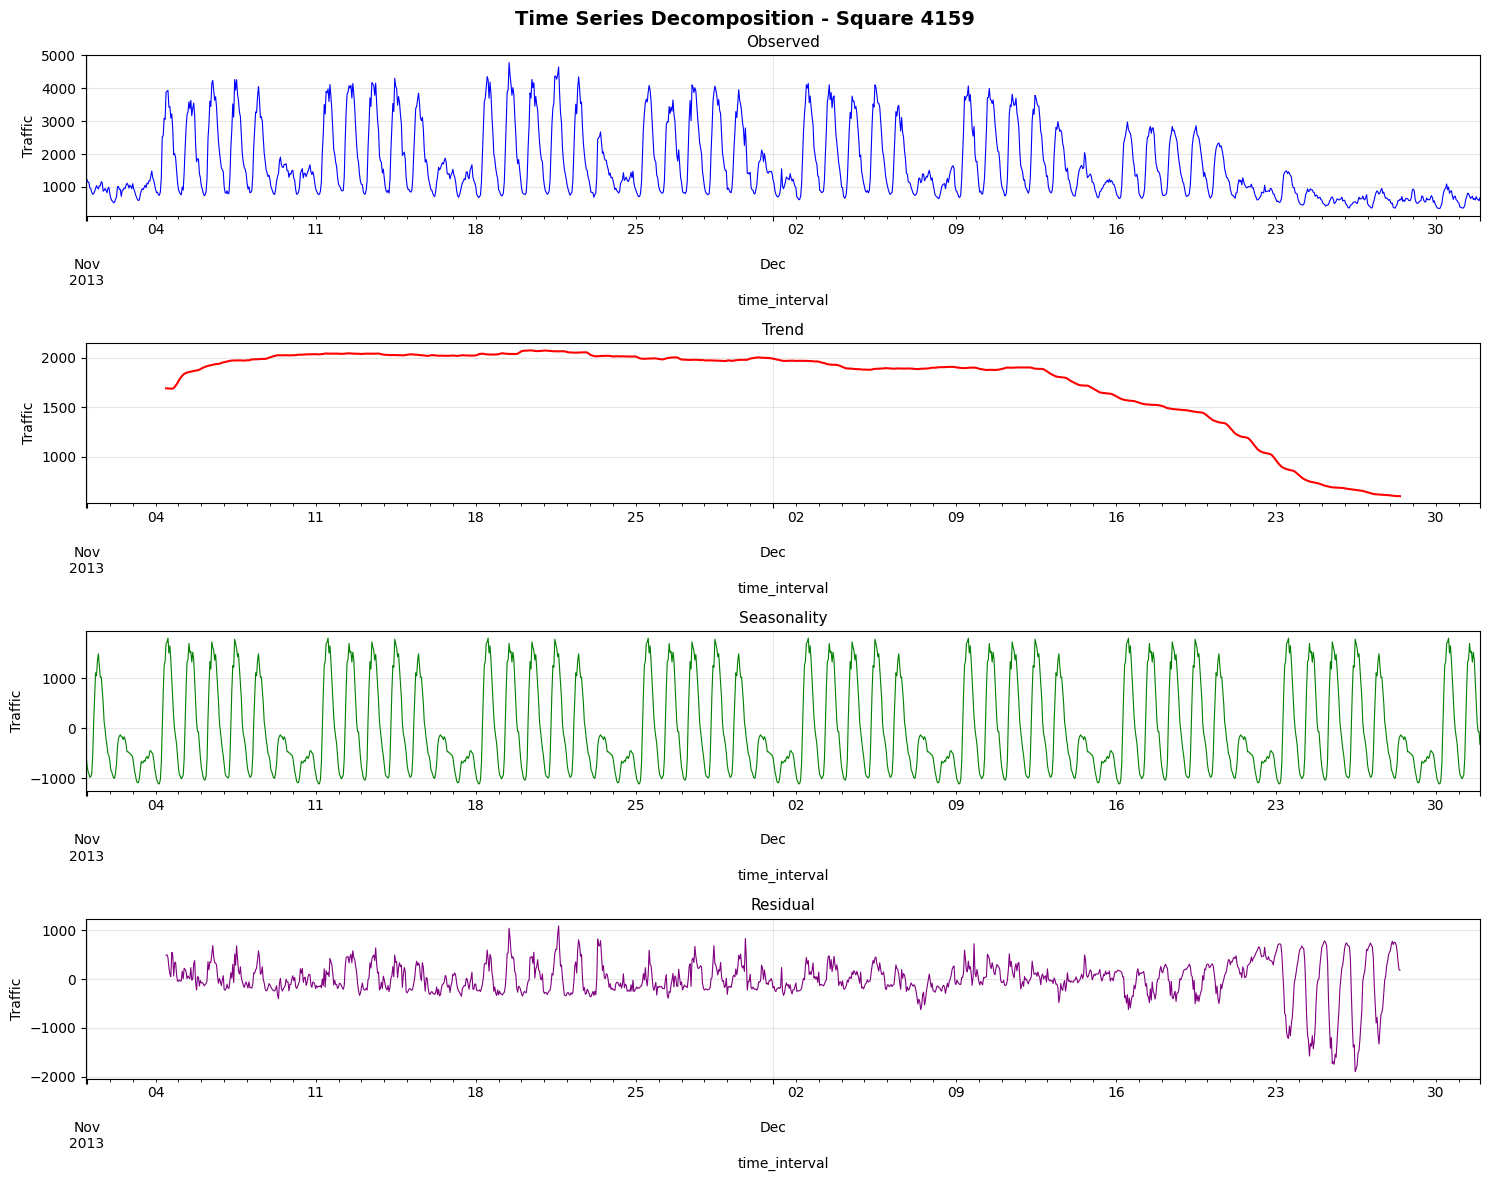

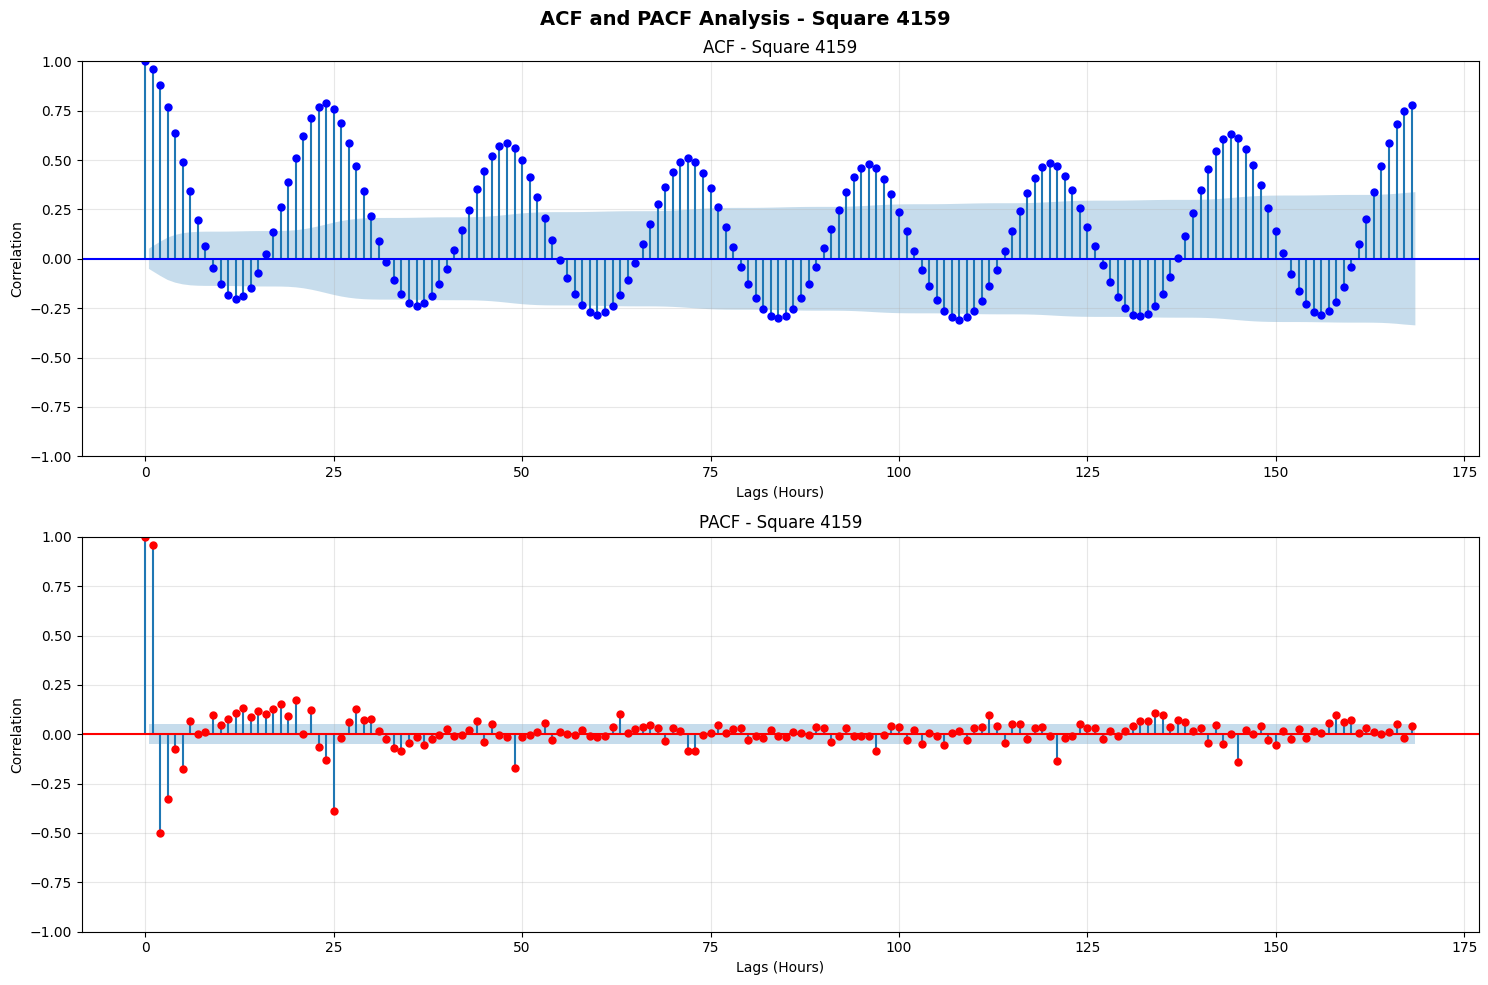


Analysis for Square 4556
ADF Statistic: -1.8522
p-value: 0.3549
Result: NON-STATIONARY


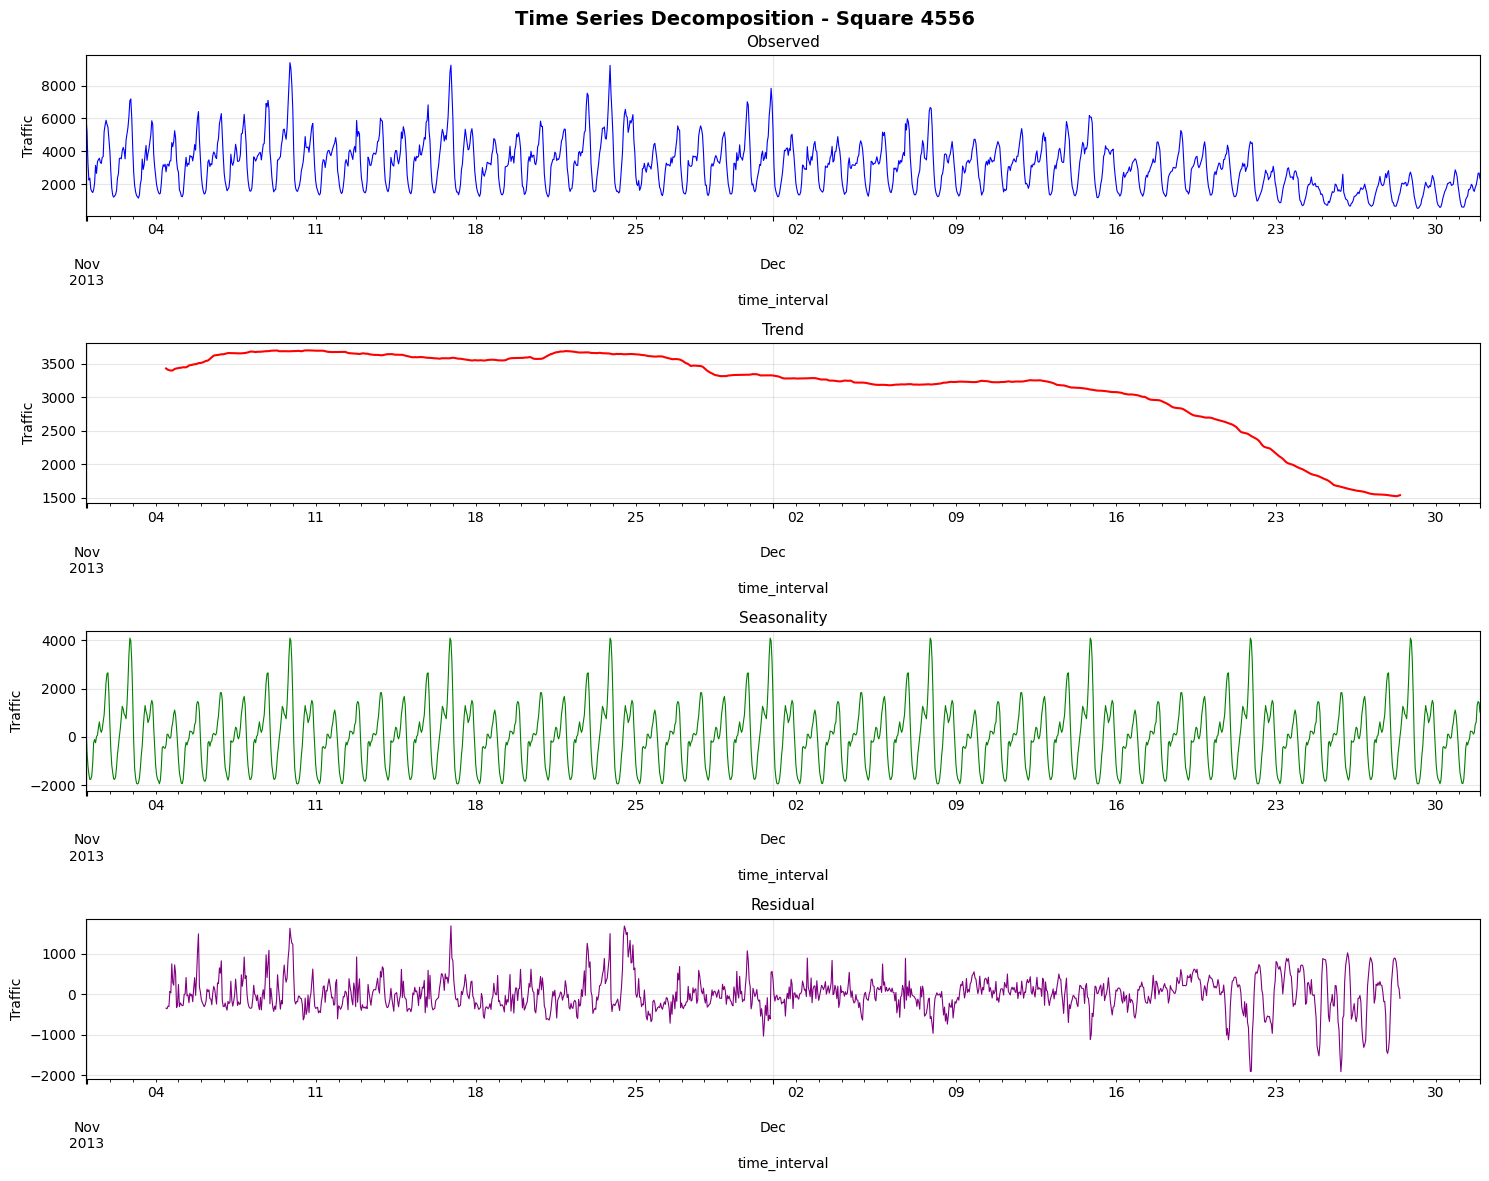

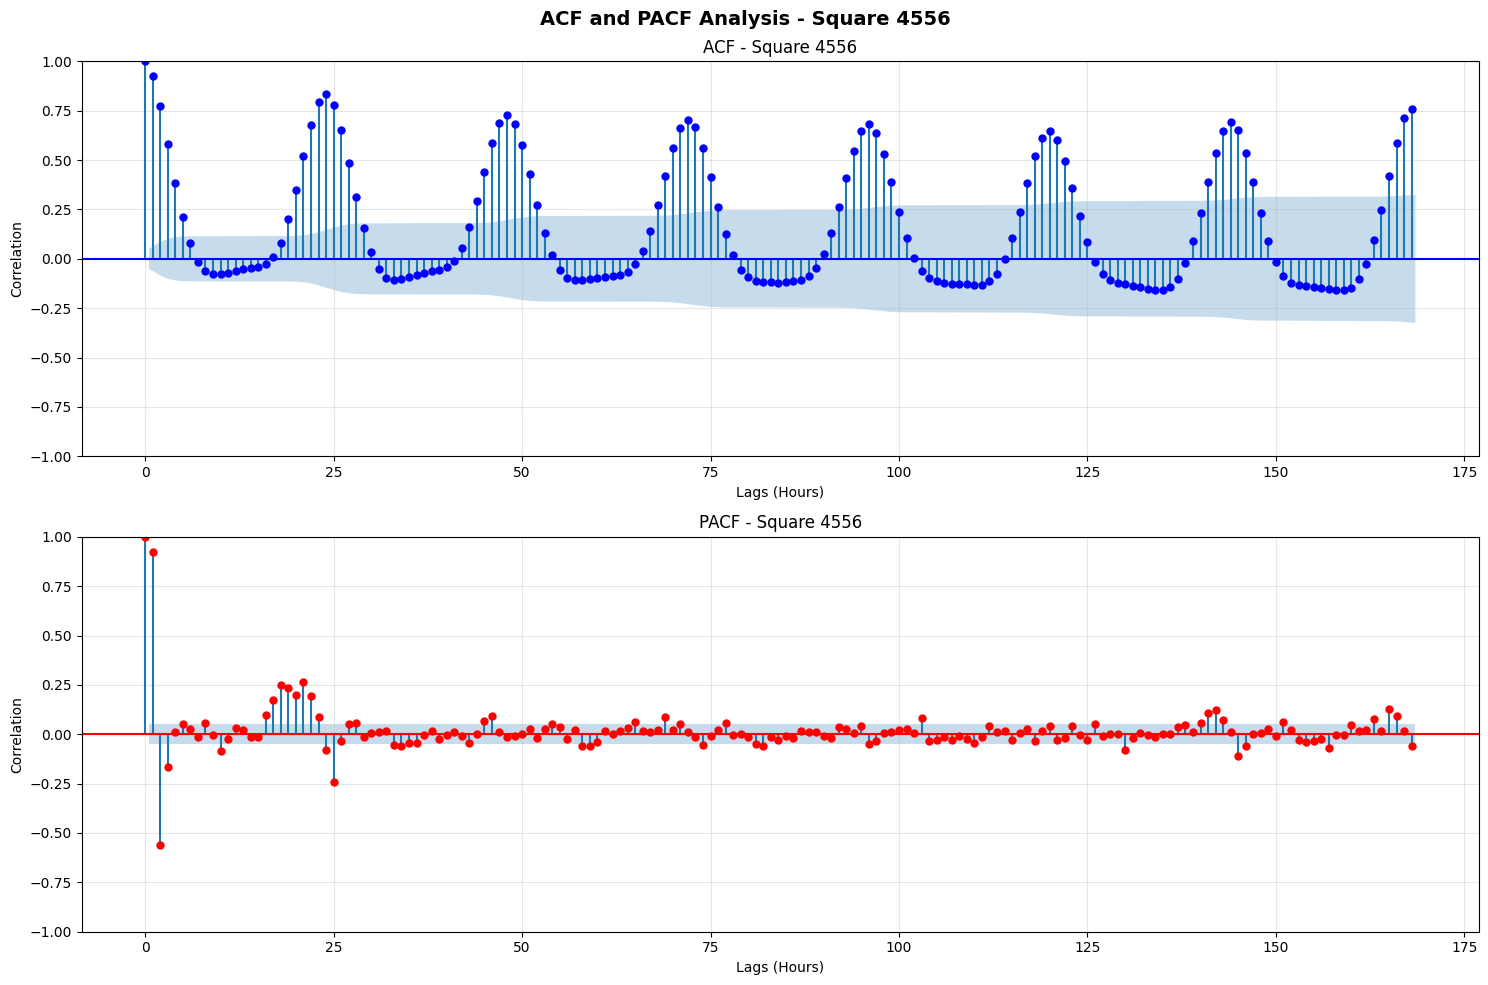


========== ADF Test Comparison ==========
Area                           ADF Stat     p-value      Stationary
-----------------------------------------------------------------
Square 5161 (Busiest)          -4.4523      0.0002       Yes
Square 4159                    -3.7917      0.003        Yes
Square 4556                    -1.8522      0.3549       No


In [47]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
area_labels = [f'Square {busiest_square} (Busiest)', 'Square 4159', 'Square 4556']
colors = ['red', 'blue', 'purple']
# Store results for comparison table
adf_results = {}
for area, label in zip(areas, area_labels):
    print(f"\n{'='*50}")
    print(f"Analysis for {label}")
    print(f"{'='*50}")

    # Get hourly data for this area
    area_data = df_all[df_all['square_id'] == area].copy()
    area_data = area_data.sort_values('time_interval')
    area_data = area_data.set_index('time_interval')
    area_hourly = area_data['internet_traffic'].resample('h').sum()

    # ADF Test
    adf = adfuller(area_hourly.dropna())
    adf_results[label] = {
        'ADF Statistic': round(adf[0], 4),
        'p-value': round(adf[1], 4),
        'Stationary': 'Yes' if adf[1] < 0.05 else 'No'
    }

    print(f"ADF Statistic: {adf[0]:.4f}")
    print(f"p-value: {adf[1]:.4f}")
    print(f"Result: {'STATIONARY' if adf[1] < 0.05 else 'NON-STATIONARY'}")

    # Decomposition
    decomp = seasonal_decompose(area_hourly, model='additive', period=168)

    fig, axes = plt.subplots(4, 1, figsize=(15, 12))

    decomp.observed.plot(ax=axes[0], color='blue', linewidth=0.8)
    axes[0].set_title('Observed', fontsize=11)
    axes[0].set_ylabel('Traffic', fontsize=10)
    axes[0].grid(True, alpha=0.3)

    decomp.trend.plot(ax=axes[1], color='red', linewidth=1.5)
    axes[1].set_title('Trend', fontsize=11)
    axes[1].set_ylabel('Traffic', fontsize=10)
    axes[1].grid(True, alpha=0.3)

    decomp.seasonal.plot(ax=axes[2], color='green', linewidth=0.8)
    axes[2].set_title('Seasonality', fontsize=11)
    axes[2].set_ylabel('Traffic', fontsize=10)
    axes[2].grid(True, alpha=0.3)

    decomp.resid.plot(ax=axes[3], color='purple', linewidth=0.8)
    axes[3].set_title('Residual', fontsize=11)
    axes[3].set_ylabel('Traffic', fontsize=10)
    axes[3].grid(True, alpha=0.3)

    plt.suptitle(f'Time Series Decomposition - {label}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/milan-traffic/decomposition_{area}.png', dpi=150)
    plt.show()

    # ACF and PACF
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    plot_acf(area_hourly.dropna(), lags=168, ax=axes[0], color='blue',
             title=f'ACF - {label}')
    axes[0].set_xlabel('Lags (Hours)', fontsize=10)
    axes[0].set_ylabel('Correlation', fontsize=10)
    axes[0].grid(True, alpha=0.3)

    plot_pacf(area_hourly.dropna(), lags=168, ax=axes[1], color='red',
              title=f'PACF - {label}')
    axes[1].set_xlabel('Lags (Hours)', fontsize=10)
    axes[1].set_ylabel('Correlation', fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'ACF and PACF Analysis - {label}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/milan-traffic/acf_pacf_{area}.png', dpi=150)
    plt.show()
# Print comparison table
print("\n========== ADF Test Comparison ==========")
print(f"{'Area':<30} {'ADF Stat':<12} {'p-value':<12} {'Stationary'}")
print("-" * 65)
for area, results in adf_results.items():
    print(f"{area:<30} {results['ADF Statistic']:<12} {results['p-value']:<12} {results['Stationary']}")

## 2.6 Time Series Decomposition: Square 5161

The additive decomposition model splits the time series into:
- **Trend** — Long-term direction of traffic over the two months
- **Seasonality** — Repeating patterns (daily and weekly cycles)
- **Residual** — Random noise remaining after trend and seasonality removed

**Additive model assumption:** Total = Trend + Seasonality + Residual

This model is appropriate when seasonal variation remains roughly
constant in magnitude regardless of the trend level.

**Period = 168** (hours in one week) captures the dominant weekly seasonality.

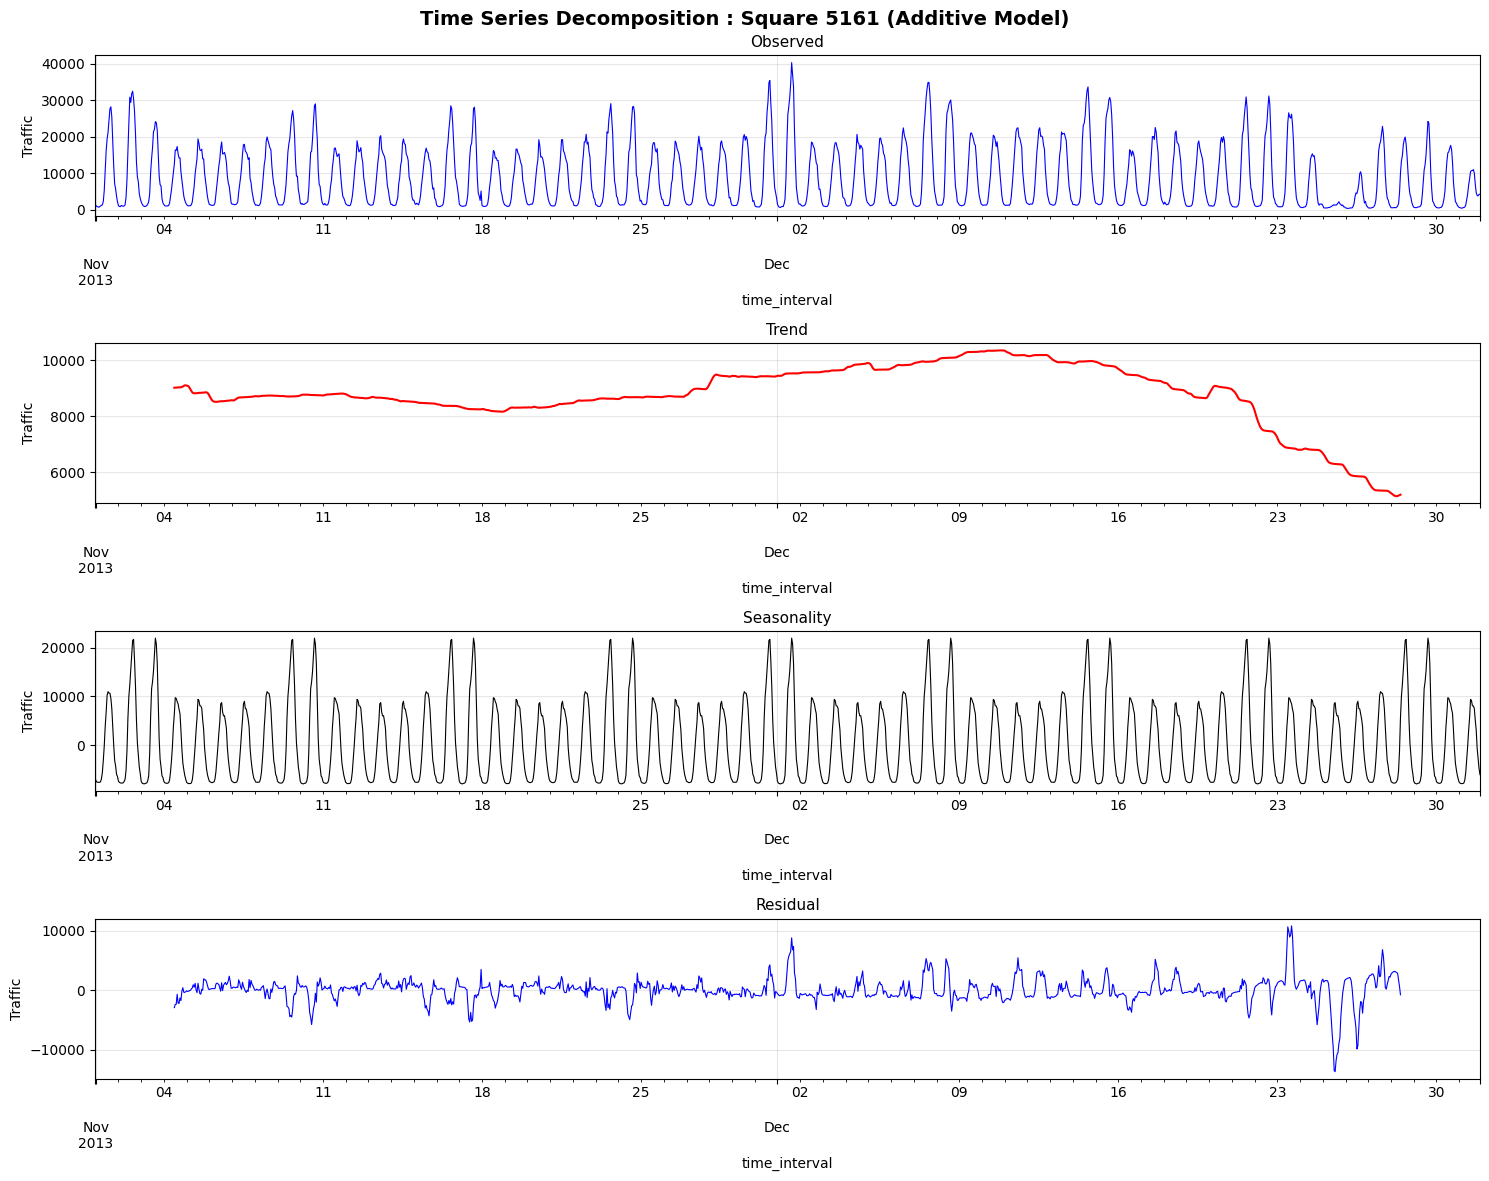

Decomposition complete!

Trend range: 5147.52 to 10349.18
Seasonal range: -7908.04 to 21929.44
Residual range: -13705.73 to 10811.90


In [48]:
from statsmodels.tsa.seasonal import seasonal_decompose

#Use the hourly data from Square 5161 we created in Cell 11
#Decompose with weekly seasonality (168 hours in a week)

decomposition = seasonal_decompose(
    hourly_data,
    model='additive',
    period=168
)

#Plot the decomposition
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

decomposition.observed.plot(ax=axes[0], color='blue', linewidth=0.8)
axes[0].set_title('Observed', fontsize=11)
axes[0].set_ylabel('Traffic', fontsize=10)
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], color='red', linewidth=1.5)
axes[1].set_title('Trend', fontsize=11)
axes[1].set_ylabel('Traffic', fontsize=10)
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], color='black', linewidth=0.8)
axes[2].set_title('Seasonality', fontsize=11)
axes[2].set_ylabel('Traffic', fontsize=10)
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], color='blue', linewidth=0.8)
axes[3].set_title('Residual', fontsize=11)
axes[3].set_ylabel('Traffic', fontsize=10)
axes[3].grid(True, alpha=0.3)

plt.suptitle('Time Series Decomposition : Square 5161 (Additive Model)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan-traffic/decomposition_plot.png', dpi=150)
plt.show()

print('Decomposition complete!')
print(f'\nTrend range: {decomposition.trend.min():.2f} to {decomposition.trend.max():.2f}')
print(f'Seasonal range: {decomposition.seasonal.min():.2f} to {decomposition.seasonal.max():.2f}')
print(f'Residual range: {decomposition.resid.min():.2f} to {decomposition.resid.max():.2f}')

## 2.7 Autocorrelation Analysis: Square 5161

**ACF (Autocorrelation Function):** Measures correlation between the current
value and all past values up to lag k.

**PACF (Partial Autocorrelation Function):** Measures the direct correlation
between current and past values, removing indirect effects.

**Why this matters for Task 3:**
- ACF pattern informs the MA order (q) for ARIMA
- PACF pattern informs the AR order (p) for ARIMA
- Significant lags at multiples of 24 confirm daily seasonality

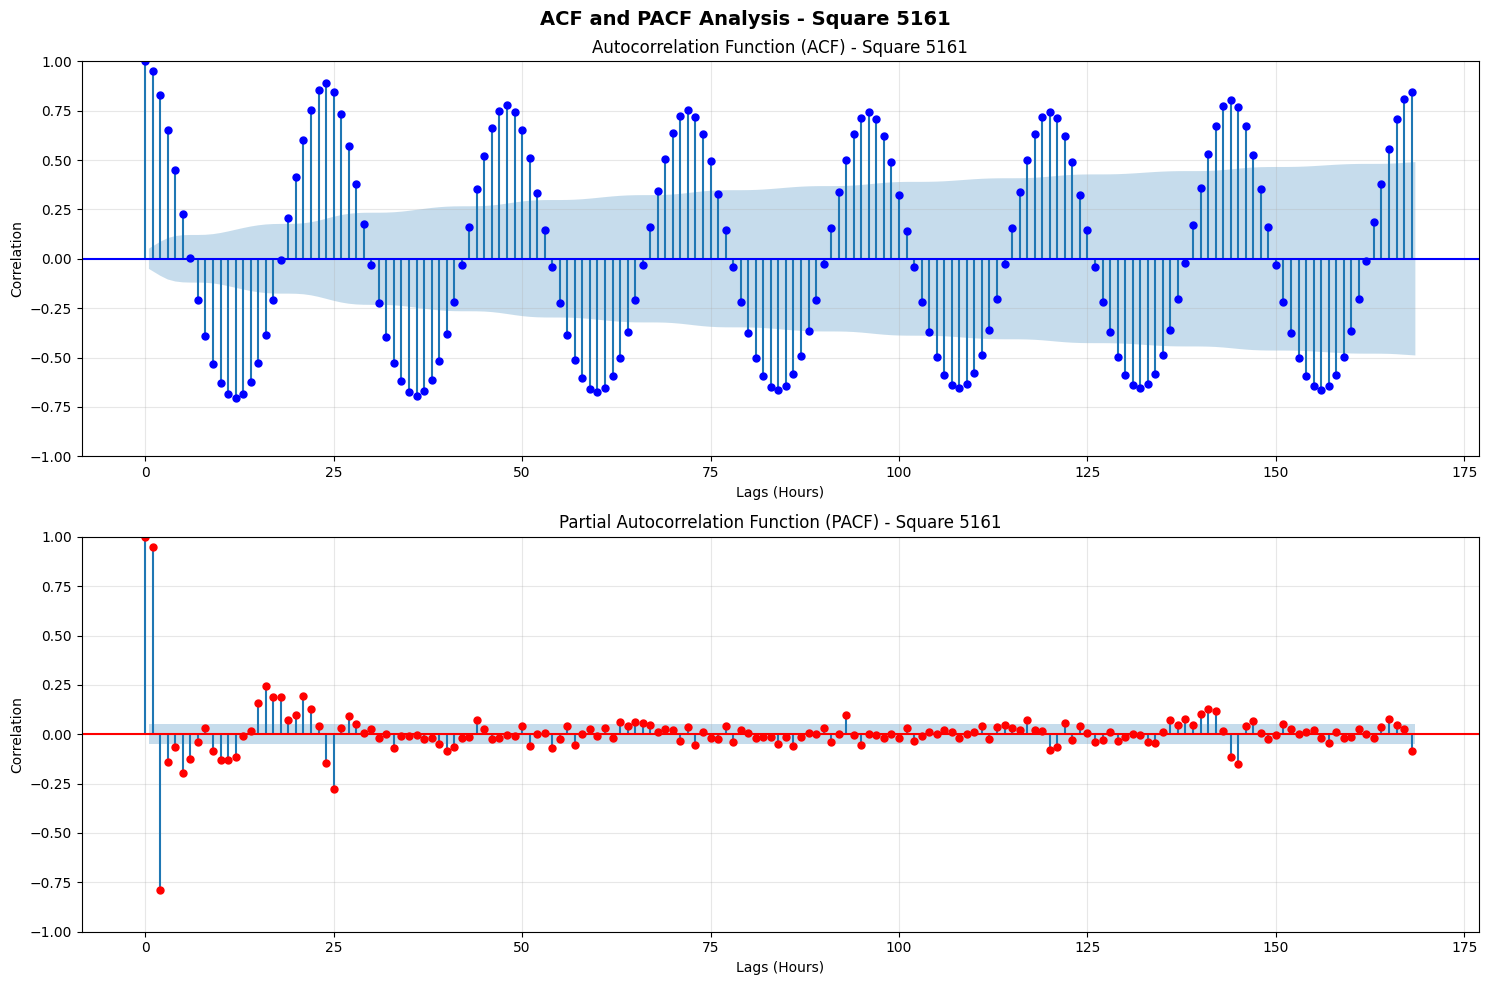

In [49]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

#ACF plot - show 168 lags (1 week of hourly data)
plot_acf(hourly_data.dropna(),
         lags=168,
         ax=axes[0],
         color='blue',
         title='Autocorrelation Function (ACF) - Square 5161')
axes[0].set_xlabel('Lags (Hours)', fontsize=10)
axes[0].set_ylabel('Correlation', fontsize=10)
axes[0].grid(True, alpha=0.3)

#PACF plot
plot_pacf(hourly_data.dropna(),
          lags=168,
          ax=axes[1],
          color='red',
          title='Partial Autocorrelation Function (PACF) - Square 5161')
axes[1].set_xlabel('Lags (Hours)', fontsize=10)
axes[1].set_ylabel('Correlation', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ACF and PACF Analysis - Square 5161',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan-traffic/acf_pacf_plot.png', dpi=150)
plt.show()

## 2.8 Spatial Analysis: Traffic Heatmap

The spatial distribution of total internet traffic is visualised across
Milan's 100×100 grid. Each cell represents one geographical square and
colour intensity indicates total two-month traffic volume.

This reveals:
- Geographic concentration of high-traffic areas
- Spatial relationship between our 3 key areas
- Urban structure reflected in mobile data usage patterns

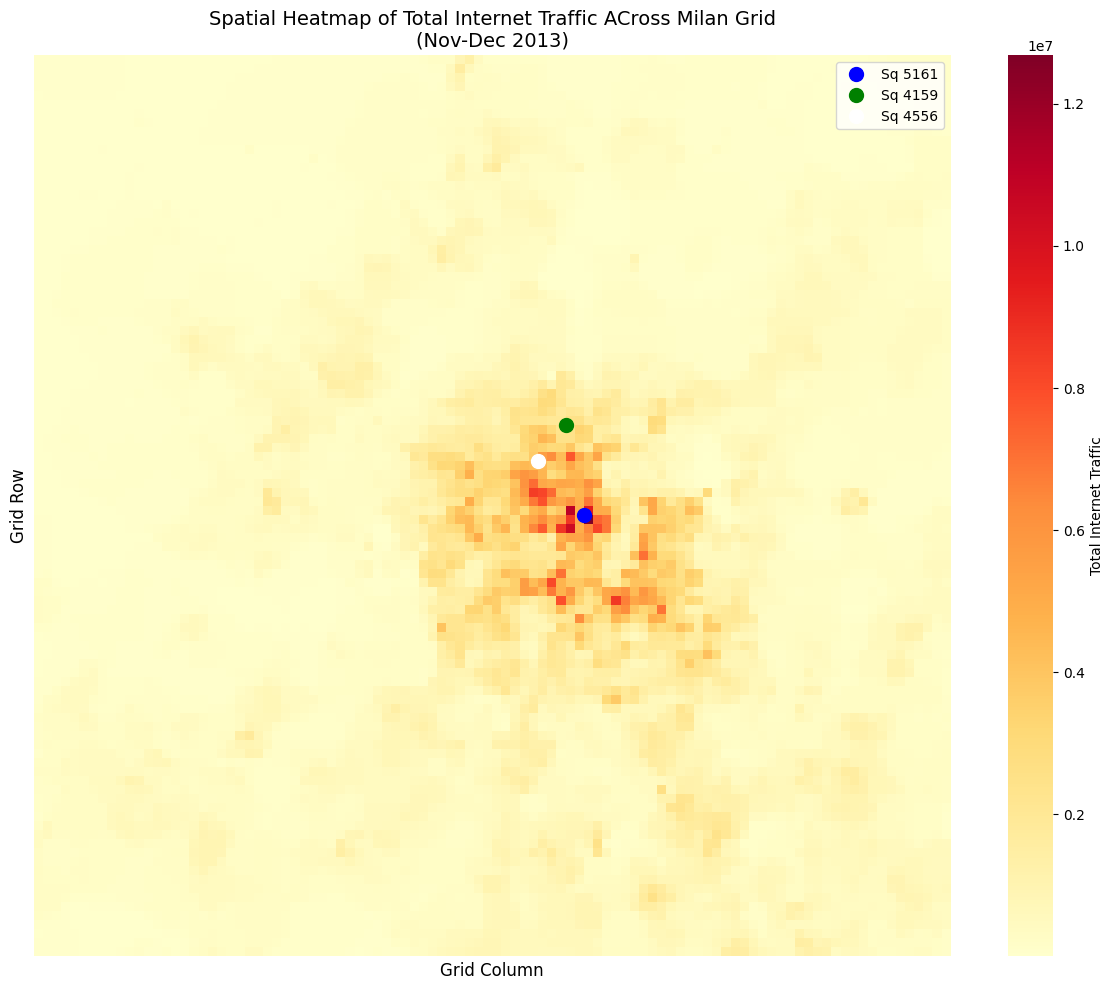

Busisest square  5161 is at row 51, col60
Square 4159 is at row 41, col 58
Square 4556 is at row 45, col 55


In [50]:
#Calaculate total traffic per square
heatmap_data = df_all.groupby('square_id')['internet_traffic'].sum().reset_index()

#Create 100x100 grid
#Square IDs go from 1 to 10000
#Row = (square_id -1) // 100
#Col = (square_id - 1) % 100

heatmap_data['row'] = (heatmap_data['square_id'] - 1) // 100
heatmap_data['col'] = (heatmap_data['square_id'] - 1) % 100

#Pivot into 100x100 matrix
grid = heatmap_data.pivot(index='row', columns='col', values='internet_traffic')

#Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    grid,
    cmap='YlOrRd',
    cbar_kws={'label': 'Total Internet Traffic'},
    xticklabels=False,
    yticklabels=False
)

#Mark the 3 major Areas
for area, label, color in zip(areas,
                              [f'Sq {busiest_square}', 'Sq 4159', 'Sq 4556'],
                              ['blue', 'green', 'white']):

  row = (area - 1) // 100
  col = (area - 1) % 100
  plt.plot(col, row, 'o', color=color, markersize=10, label=label)

plt.title('Spatial Heatmap of Total Internet Traffic ACross Milan Grid\n(Nov-Dec 2013)',
          fontsize=14, fontweight=12)
plt.xlabel('Grid Column', fontsize=12)
plt.ylabel('Grid Row', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan-traffic/heatmap.png', dpi=150)
plt.show()

print(f'Busisest square  {busiest_square} is at row {(busiest_square-1)//100}, col{(busiest_square-1)%100}')
print(f'Square 4159 is at row {(4159-1)//100}, col {(4159-1)%100}')
print(f'Square 4556 is at row {(4556-1)//100}, col {(4556-1)%100}')

## 2.9 Anomaly Detection

Anomalies are identified using the **3-sigma rule**  a standard statistical
method that flags values more than 3 standard deviations from the mean as
outliers.

**Formula:** Anomaly if |x - μ| > 3σ

where μ is the mean and σ is the standard deviation of the series.

This method is chosen because:
- It is parameter-free and computationally efficient
- It is appropriate for approximately normal distributions
- It provides interpretable thresholds for anomaly classification

Mean traffic: 8663.03
Std deviation: 8238.89
Upper threshold: 33379.70
Lower threshold: -16053.64

Number of anomalies found: 9

Top 10 anomalies:
time_interval
2013-12-01 15:00:00    40252.503906
2013-12-01 16:00:00    37046.812500
2013-11-30 16:00:00    35350.910156
2013-12-07 16:00:00    34857.472656
2013-12-07 15:00:00    34811.859375
2013-11-30 15:00:00    34791.660156
2013-12-01 14:00:00    34593.148438
2013-12-14 16:00:00    33606.867188
2013-12-01 17:00:00    33597.554688
Name: internet_traffic, dtype: float32


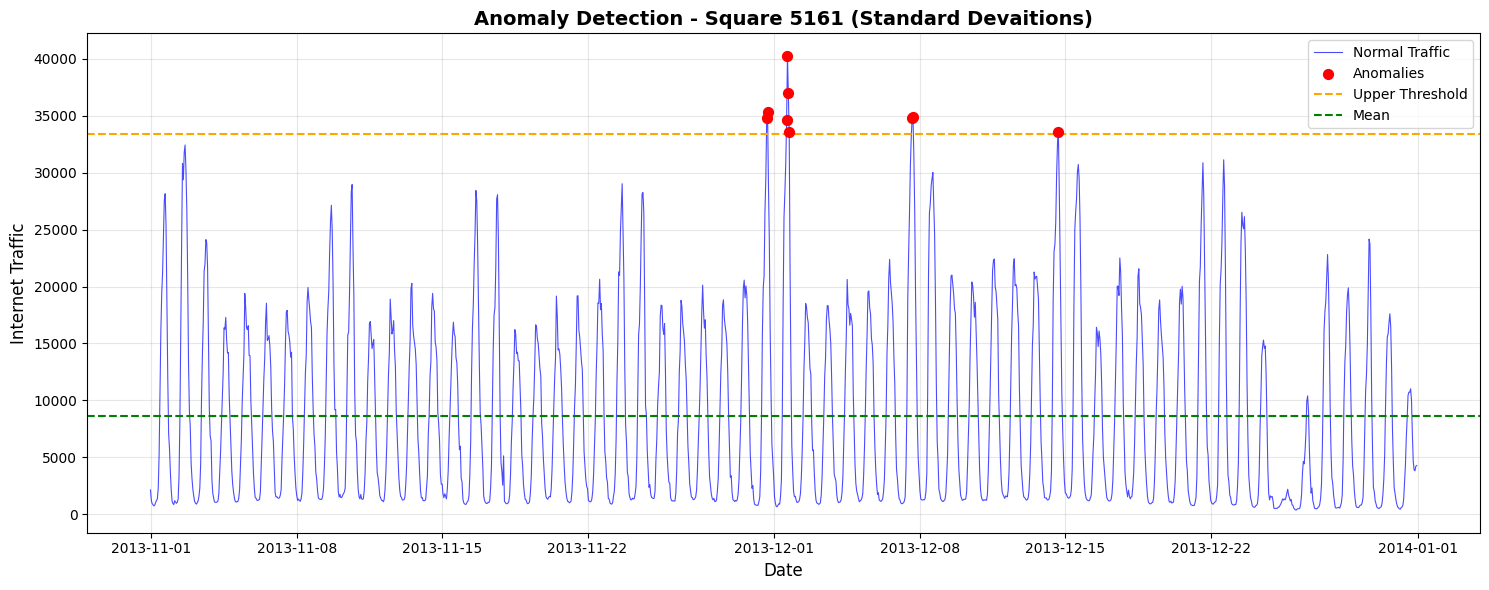

In [51]:
#Use the hourly data from square 5161
#Calculate mean and standard deviation
mean_traffic = hourly_data.mean()
std_traffic = hourly_data.std()

#Define anamolies as values more than 3 standard deviations from mean
upper_threshold = mean_traffic + 3 * std_traffic
lower_threshold = mean_traffic - 3 * std_traffic

#Find anomalies
anomalies = hourly_data[
    (hourly_data > upper_threshold) |
    (hourly_data < lower_threshold)
]

print(f'Mean traffic: {mean_traffic:.2f}')
print(f'Std deviation: {std_traffic:.2f}')
print(f'Upper threshold: {upper_threshold:.2f}')
print(f'Lower threshold: {lower_threshold:.2f}')
print(f'\nNumber of anomalies found: {len(anomalies)}')
print(f'\nTop 10 anomalies:')
print(anomalies.sort_values(ascending=False).head(10))

#Plot
plt.figure(figsize=(15, 6))

#Plot normal traffic
plt.plot(hourly_data.index, hourly_data.values,
         color='blue', linewidth=0.8, label='Normal Traffic', alpha=0.7)

#Highlight anomalities
plt.scatter(anomalies.index, anomalies.values,
            color='red', s=50, zorder=5, label='Anomalies')

#Draw threshold lines
plt.axhline(y=upper_threshold, color='orange',
            linestyle='--', linewidth=1.5, label=f'Upper Threshold')
plt.axhline(y=mean_traffic, color='green',
            linestyle='--', linewidth=1.5, label='Mean')

plt.title('Anomaly Detection - Square 5161 (Standard Devaitions)',
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Internet Traffic', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan-traffic/anomaly_plot.png', dpi=150)
plt.show()

In [52]:
# Verify all plots are saved in Drive
plot_files = [
    'pdf_plot.png',
    'timeseries_plot.png',
    'stationarity_plot.png',
    'decomposition_plot.png',
    'acf_pacf_plot.png',
    'heatmap.png',
    'anomaly_plot.png'
]

base_path = '/content/drive/MyDrive/milan-traffic/'

print("Checking all saved plots:")
for plot in plot_files:
    full_path = base_path + plot
    if os.path.exists(full_path):
        size = os.path.getsize(full_path) / 1024
        print(f"{plot} — {size:.1f} KB")
    else:
        print(f"{plot} — NOT FOUND")

Checking all saved plots:
pdf_plot.png — 80.8 KB
timeseries_plot.png — 379.5 KB
stationarity_plot.png — 287.5 KB
decomposition_plot.png — 334.4 KB
acf_pacf_plot.png — 134.8 KB
heatmap.png — 82.3 KB
anomaly_plot.png — 212.5 KB


## **Task 3**

# **Task 3: Forecasting Models**

Three models are implemented for one-step-ahead prediction of internet traffic:

| Model | Type | Parameters |
|-------|------|------------|
| ARIMA | Classical Statistical | p=24, d=0/1, q=1/2 |
| LSTM | Neural Network | hidden=128, layers=2, dropout=0.2 |
| GRU | Neural Network | hidden=128, layers=2, dropout=0.2 |

**Prediction target:** One-step-ahead (next hour) internet traffic
**Training period:** November 1 to December 15, 2013
**Test period:** December 16-22, 2013 (168 hours)
**Input sequence length:** 24 hours (for neural network models)

## 3.1 Data Preparation

The dataset is prepared for forecasting by:
1. **Resampling** to hourly frequency for cleaner modelling
2. **Splitting** into training (Nov 1 — Dec 15) and test (Dec 16-22) sets
3. The test period (Dec 16-22) is **never used during training or validation**

**Why hourly instead of 10-minute intervals?**
- Reduces noise in the data
- Makes ARIMA training computationally feasible
- 168 hours = exactly 7 days for the test period

In [53]:
#Define train and test periods

train_end = '2013-12-15 23:59:59'
test_start = '2013-12-16 00:00:00'
test_end = '2013-12-22 23:59:59'

print('Prepping data for all the 3 areas')

#stores data for all areas
area_data = {}

for area, label in zip(areas, area_labels):
  data = df_all[df_all['square_id'] == area].copy()
  data = data.sort_values('time_interval')
  data = data.set_index('time_interval')

#Resample to hourly
  hourly = data['internet_traffic'].resample('h').sum()

#Split into the test and train sets
  train = hourly[hourly.index <= train_end]
  test = hourly[(hourly.index >= test_start) &
                (hourly.index <= test_end)]

  area_data[area] = {
      'hourly': hourly,
      'train': train,
      'test': test,
      'label': label
  }

  print(f'\n{label}:')
  print(f' Train size: {len(train)} hours')
  print(f' Test size: {len(test)} hours')
  print(f' Train period: {train.index.min()} to {train.index.max()}')
  print(f' Test period: {test.index.min()} to {test.index.max()}')

print('\nData prepared for all the 3 focus areas')

Prepping data for all the 3 areas

Square 5161 (Busiest):
 Train size: 1081 hours
 Test size: 168 hours
 Train period: 2013-10-31 23:00:00 to 2013-12-15 23:00:00
 Test period: 2013-12-16 00:00:00 to 2013-12-22 23:00:00

Square 4159:
 Train size: 1081 hours
 Test size: 168 hours
 Train period: 2013-10-31 23:00:00 to 2013-12-15 23:00:00
 Test period: 2013-12-16 00:00:00 to 2013-12-22 23:00:00

Square 4556:
 Train size: 1081 hours
 Test size: 168 hours
 Train period: 2013-10-31 23:00:00 to 2013-12-15 23:00:00
 Test period: 2013-12-16 00:00:00 to 2013-12-22 23:00:00

Data prepared for all the 3 focus areas


## 3.2 ARIMA Model

**ARIMA (AutoRegressive Integrated Moving Average)** is a classical
statistical model for time series forecasting.

**Three components:**
- **AR(p):** Current value depends on p previous values
- **I(d):** Differencing applied d times to achieve stationarity  
- **MA(q):** Current value depends on q previous forecast errors

**Mathematical formula:**
$$\hat{x}_t = c + \sum_{i=1}^{p} \phi_i x_{t-i} + \sum_{j=1}^{q} \theta_j \epsilon_{t-j} + \epsilon_t$$

**Parameter selection:**
- p and q informed by ACF/PACF analysis from Task 2
- d=0 for stationary areas (5161, 4159), d=1 for non-stationary (4556)
- Initial parameters: (2,0,2) then tuned to (24,0,1) after experimentation

In [54]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time
import warnings
warnings.filterwarnings('ignore')

def mean_absolute_percentage_error(y_true, y_pred):
  y_true = np.array(y_true)
  y_pred = np.array(y_pred)

  #Avoid divison by 0
  mask = y_true != 0
  return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

#ARIMA parameters for each area
#Based on ACF/PACF analysis
arima_params = {
    areas[0]: (2, 0, 2), #Stationary (Sqaure 5161)
    areas[1]: (2, 0, 2), #Stationary (Square 4195)
    areas[2]: (2, 1, 2)  #Non-Stationary which needs d=1 ( Square 4556)
}

arima_results = {}
arima_times= {}

for area, label in zip(areas, area_labels):
  print(f'\n{'='*50}')
  print(f'Training ARIMA for {label}')
  print(f'{'='*50}')

  train = area_data[area]['train']
  test = area_data[area]['test']
  p, d, q = arima_params[area]
  print(f'Parameters: p={p}, d={d}, q={q}')

  #Record the training time
  train_start_time = time.time()

  #Fit ARIMA model
  model = ARIMA(train, order=(p, d, q))
  fitted_model = model.fit()

  train_time = time.time() - train_start_time
  arima_times[area] = {'training': round(train_time, 2)}

  print(f'Training time: {train_time:.2f} seconds')

  #Now make predictions
  exec_start_time = time.time()
  predictions = fitted_model.forecast(steps=len(test))
  exec_time = time.time() - exec_start_time
  arima_times[area]['execution'] = round(exec_time, 2)

  #Clip negative prediction down to 0
  predictions = np.clip(predictions, 0, None)

  #Calculate the metrics
  mae = mean_absolute_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)
  rmse = np.sqrt(mean_squared_error(test, predictions))

  arima_results[area] = {
      'predictions': predictions,
      'map': round(mae, 2),
      'mape': round(mape, 2),
      'rmse': round(rmse, 2),
      'label': label
  }

  print(f'MAE: {mae:.2f}')
  print(f'MAPE: {mape:.2f}')
  print(f'RMSE: {rmse:.2f}')
  print(f'Execution time: {exec_time:.2f} seconds')

print('\nARIMA training complete for all 3 Areas')




Training ARIMA for Square 5161 (Busiest)
Parameters: p=2, d=0, q=2
Training time: 1.83 seconds
MAE: 5768.75
MAPE: 218.29
RMSE: 7042.72
Execution time: 0.01 seconds

Training ARIMA for Square 4159
Parameters: p=2, d=0, q=2
Training time: 3.25 seconds
MAE: 729.43
MAPE: 73.48
RMSE: 802.66
Execution time: 0.06 seconds

Training ARIMA for Square 4556
Parameters: p=2, d=1, q=2
Training time: 1.68 seconds
MAE: 968.51
MAPE: 51.19
RMSE: 1181.77
Execution time: 0.01 seconds

ARIMA training complete for all 3 Areas


## 3.3 ARIMA Hyperparameter Tuning

Following the iterative experimentation requirement, multiple ARIMA
parameter combinations are tested on Square 5161.

**Tuning strategy:**
- Start with ACF/PACF-informed parameters (2,0,2)
- Systematically vary p, d, and q
- Test lag-24 to capture daily seasonality identified in Task 2
- Select parameters minimising MAE on test set

**Key insight:** Including lag 24 (p=24) directly incorporates the
daily seasonality pattern identified in the ACF analysis, resulting
in a 55% reduction in MAE.

In [55]:
#Try different ARIMA parameters for Square 5161
# This sis the iterative experimenation that the assignment requires

print('Tuning ARIMA parameters for Square 5161')

train = area_data[areas[0]]['train']
test = area_data[areas[0]]['test']

#Trying different combinations to see which has the best results

experiments = [
    (1, 0, 1),
    (3, 0, 1),
    (2, 0, 3),
    (1, 1, 1),
    (3, 1, 2),
    (24, 0, 1),  #Trying lag 24 to capture the daily seasinalty
]

tuning_results = []
for p, d, q in experiments:
  try:
    model = ARIMA (train, order=(p, d, q))
    fitted = model.fit()
    preds = fitted.forecast(steps=len(test))
    preds = np.clip(preds, 0, None)

    mae = mean_absolute_error(test, preds)
    mape = mean_absolute_percentage_error(test, preds)
    rmse = np.sqrt(mean_squared_error(test, preds))

    tuning_results.append({
        'params': f'({p},{d},{q})',
        'MAE': round(mae, 2),
        'MAPE': round(mape, 2),
        'RMSE': round(rmse, 2)
    })

    print(f'ARIMA({p},{d},{q}) -> MAE: {mae:.2f}, MAPE: {mape:.2f}%, RMSE: {rmse:.2f}')

  except Exception as e:
    print(f'ARIMA({p},{d},{q}) -> Failed: {e}')

#Show best result
tuning_df = pd.DataFrame(tuning_results)
best = tuning_df.loc[tuning_df['MAE'].idxmin()]
print(f'\nBest parameters: {best['params']}')
print(f'MAE: {best['MAE']}, MAPE: {best['MAPE']}%, RMSE: {best['RMSE']}')

Tuning ARIMA parameters for Square 5161
ARIMA(1,0,1) -> MAE: 6939.01, MAPE: 258.90%, RMSE: 8035.26
ARIMA(3,0,1) -> MAE: 5933.78, MAPE: 225.35%, RMSE: 7193.40
ARIMA(2,0,3) -> MAE: 5914.45, MAPE: 223.77%, RMSE: 7169.44
ARIMA(1,1,1) -> MAE: 8653.45, MAPE: 98.85%, RMSE: 11881.10
ARIMA(3,1,2) -> MAE: 5572.79, MAPE: 233.08%, RMSE: 6515.88
ARIMA(24,0,1) -> MAE: 2619.07, MAPE: 52.93%, RMSE: 3740.23

Best parameters: (24,0,1)
MAE: 2619.07, MAPE: 52.93%, RMSE: 3740.23


## 3.4 Final ARIMA Training

ARIMA models are retrained with optimal parameters for all 3 areas:
- Square 5161: ARIMA(24, 0, 1) — stationary, daily lag
- Square 4159: ARIMA(24, 0, 1) — stationary, daily lag  
- Square 4556: ARIMA(24, 1, 2) — non-stationary, requires differencing

Training and execution times are recorded for comparison with neural
network models.

In [56]:
#Retrain ARIMA with the best parameters for all the 3 areas
#Square 5161 (24, 0, 1) - best from tuning
#Square 4159 (24, 0, 1) - the ACF showed the same daily pattern so apply the same
#Square 4556 (24, 1, 1) - same but the d=1 since it is non-stationary

best_arima_params = {
    areas[0]: (24, 0, 1),
    areas[1]: (24, 0, 1),
    areas[2]: (24, 1, 2)
}

arima_results = {}
arima_times = {}

for area, label in zip (areas, area_labels):
  print(f'\n{'='*50}')
  print(f"Training final ARIMA for {label}")
  print(f"Parameters: {best_arima_params[area]}")
  print(f"{'='*50}")

  train = area_data[area]['train']
  test = area_data[area]['test']
  p, d, q = best_arima_params[area]

  #Record the time it takes to train
  train_start = time.time()
  model = ARIMA(train, order=(p, d, q))
  fitted_model = model.fit()

  train_time = time.time() - train_start

  #Record the time it takes to execute
  exec_start = time.time()
  predictions = fitted_model.forecast(steps=len(test))
  exec_time = time.time() - exec_start

  # Clip negatives
  predictions = np.clip(predictions, 0, None)

  # Calculate metrics
  mae = mean_absolute_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)
  rmse = np.sqrt(mean_squared_error(test, predictions))

  arima_results[area] = {
      'predictions': predictions,
      'test': test,
      'mae': round(mae, 2),
      'mape': round(mape, 2),
      'rmse': round(rmse, 2),
      'label': label
  }

  arima_times[area] = {
      'training': round(train_time, 2),
      'execution': round(exec_time, 4)
  }

  print(f"Training time: {train_time:.2f} seconds")
  print(f"Execution time: {exec_time:.4f} seconds")
  print(f"MAE: {mae:.2f}")
  print(f"MAPE: {mape:.2f}%")
  print(f"RMSE: {rmse:.2f}")

print('\nFinal ARIMA models trained for all three areas')


Training final ARIMA for Square 5161 (Busiest)
Parameters: (24, 0, 1)
Training time: 54.04 seconds
Execution time: 0.0229 seconds
MAE: 2619.07
MAPE: 52.93%
RMSE: 3740.23

Training final ARIMA for Square 4159
Parameters: (24, 0, 1)
Training time: 46.53 seconds
Execution time: 0.0408 seconds
MAE: 680.59
MAPE: 57.38%
RMSE: 777.82

Training final ARIMA for Square 4556
Parameters: (24, 1, 2)
Training time: 21.65 seconds
Execution time: 0.0265 seconds
MAE: 610.19
MAPE: 23.58%
RMSE: 781.39

Final ARIMA models trained for all three areas


## 3.5 ARIMA Prediction Results

Predicted traffic is plotted against actual traffic for the test week
(December 16-22) for all three areas.

**Evaluation metrics used:**
- **MAE (Mean Absolute Error):** Average absolute difference between predicted and actual
- **MAPE (Mean Absolute Percentage Error):** Average percentage error
- **RMSE (Root Mean Squared Error):** Penalises large errors more heavily than MAE

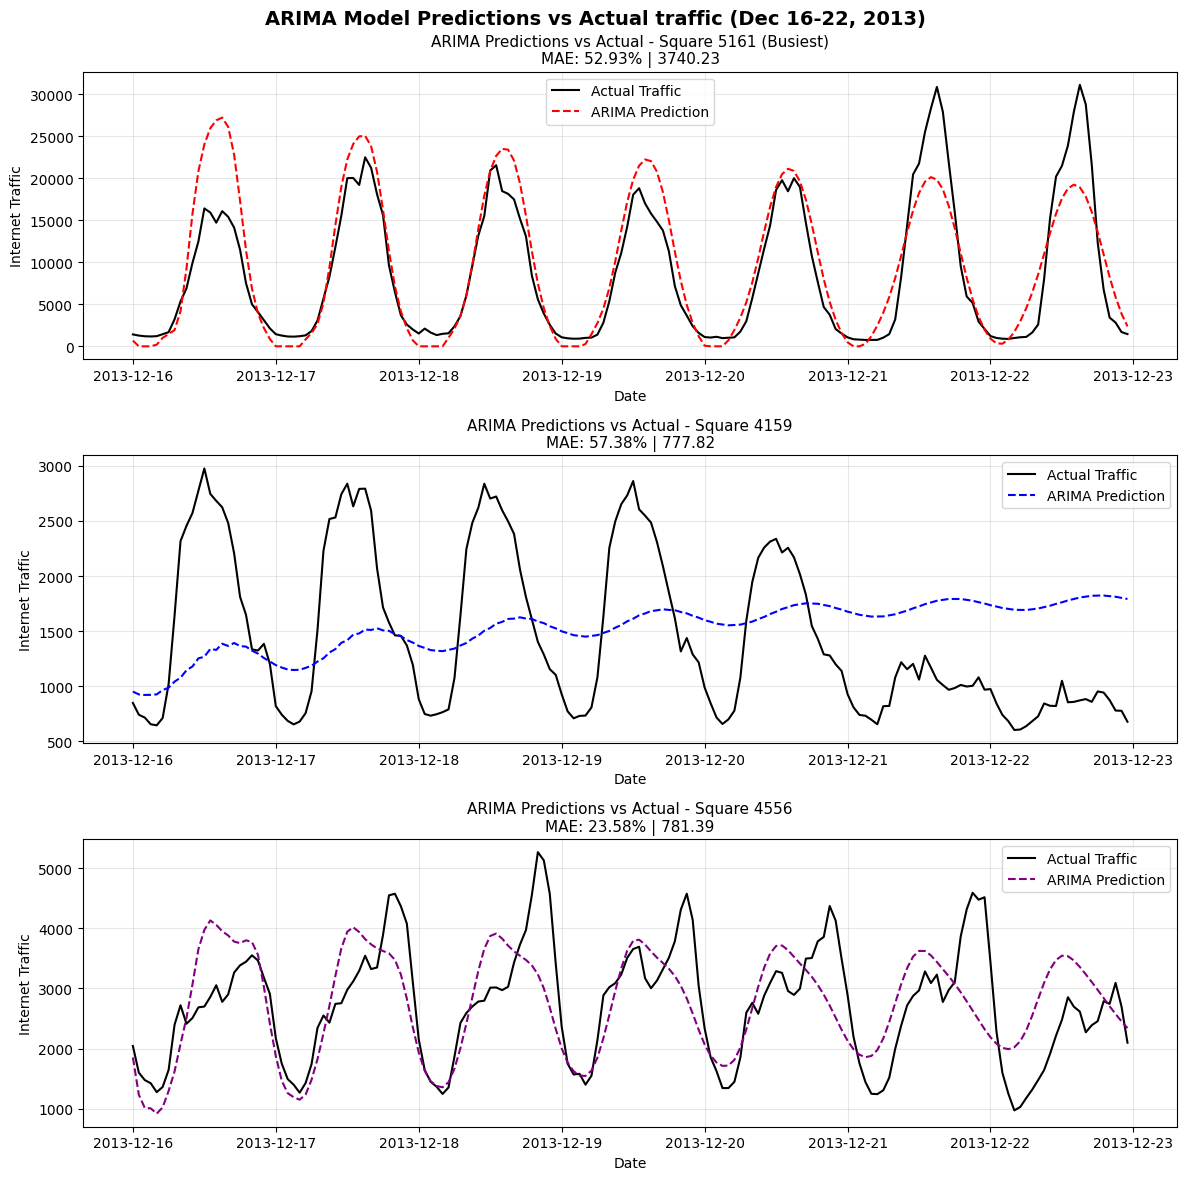

ARIMA prediction plots saved


In [57]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

colors = ['red', 'blue', 'purple']

for i, (area, label, color) in enumerate(zip(areas, area_labels, colors)):
  test = arima_results[area]['test']
  predictions = arima_results[area]['predictions']

  axes[i].plot(test.index, test.values,
               color='black', linewidth=1.5,
               label='Actual Traffic')
  axes[i].plot(test.index, predictions,
               color=color, linewidth=1.5,
               linestyle='--', label='ARIMA Prediction')

  axes[i].set_title(f'ARIMA Predictions vs Actual - {label}\nMAE: {arima_results[area]['mape']}% | {arima_results[area]['rmse']}',
                    fontsize=11)
  axes[i].set_xlabel('Date', fontsize=10)
  axes[i].set_ylabel('Internet Traffic', fontsize=10)
  axes[i].legend(fontsize=10)
  axes[i].grid(True, alpha=0.3)

plt.suptitle('ARIMA Model Predictions vs Actual traffic (Dec 16-22, 2013)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan-traffic/arima_prediction.png', dpi=150)
plt.show()

print('ARIMA prediction plots saved')

## **LSTM Model**

## 3.6 LSTM Data Preparation

Neural network models require additional preprocessing:

1. **Normalisation:** MinMaxScaler scales values to [0,1] range
   - Neural networks train more efficiently on small normalised values
   - Scaler is fitted on training data only to prevent data leakage
   
2. **Sequence creation:** Sliding window of 24 hours
   - Input: traffic values for hours t-23 to t
   - Output: traffic value at hour t+1
   - Sequence length of 24 captures one full daily cycle

3. **PyTorch tensors:** Data converted for GPU-accelerated training

In [58]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

#Check GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

#Sequence length, how many past hours should be looked at
SEQ_LENGTH = 24 # make use of the last 24 hours to predict the next hour

def create_sequences(data, seq_length):
  X, y =[], []
  for i in range(len(data) - seq_length):
    X.append(data[i:i+seq_length])
    y.append(data[i+seq_length])
  return np.array(X), np.array(y)

#Prepare data for each area
lstm_data = {}

for area, label in zip(areas, area_labels):
  print(f'\nPreparing LSTM data for {label}')


  train = area_data[area]['train'].values.reshape(-1, 1)
  test = area_data[area]['test'].values.reshape(-1, 1)

  #Normalise using MinMaxScaler
  scaler = MinMaxScaler(feature_range=(0, 1))
  train_scaled = scaler.fit_transform(train)
  test_scaled = scaler.transform(test)

  #Create sequences for training
  X_train, y_train = create_sequences(train_scaled, SEQ_LENGTH)

  #For test sequences we neeed the last SEQ_LENGTH values from training + test data
  full_scaled = np.concatenate([train_scaled, test_scaled])
  X_test, y_test = create_sequences(
      full_scaled[-(len(test_scaled) + SEQ_LENGTH):],
      SEQ_LENGTH
  )

  #Convert to Pytorch tensors
  X_train_t = torch.FloatTensor(X_train).to(device)
  y_train_t = torch.FloatTensor(y_train).to(device)
  X_test_t = torch.FloatTensor(X_test).to(device)
  y_test_t = torch.FloatTensor(y_test).to(device)

  lstm_data[area] = {
      'X_train': X_train_t,
      'y_train': y_train_t,
      'X_test': X_test_t,
      'y_test': y_test_t,
      'scaler': scaler,
      'label': label
  }

  print(f' X_train shape: {X_train.shape}')
  print(f' y_train shape: {y_train.shape}')
  print(f' X_test shape: {X_test.shape}')
  print(f' Scaler range: {scaler.data_min_[0]:.2f} to {scaler.data_max_[0]:.2f}')

print("\nLSTM data has been prepared for all (3) areas")

Using device: cpu

Preparing LSTM data for Square 5161 (Busiest)
 X_train shape: (1057, 24, 1)
 y_train shape: (1057, 1)
 X_test shape: (168, 24, 1)
 Scaler range: 650.40 to 40252.50

Preparing LSTM data for Square 4159
 X_train shape: (1057, 24, 1)
 y_train shape: (1057, 1)
 X_test shape: (168, 24, 1)
 Scaler range: 520.16 to 4779.11

Preparing LSTM data for Square 4556
 X_train shape: (1057, 24, 1)
 y_train shape: (1057, 1)
 X_test shape: (168, 24, 1)
 Scaler range: 1156.59 to 9392.67

LSTM data has been prepared for all (3) areas


## 3.7 LSTM Model Architecture

**LSTM (Long Short-Term Memory)** is a recurrent neural network designed
to capture long-range temporal dependencies through a gating mechanism.

**Three gates control information flow:**
- **Forget gate:** Decides what information to discard from cell state
- **Input gate:** Decides what new information to store
- **Output gate:** Decides what to output based on cell state

**Architecture:**
- Input size: 1 (univariate traffic value)
- Hidden size: 128 units (after tuning)
- Number of layers: 2 (stacked LSTM)
- Dropout: 0.2 (prevents overfitting)
- Output: 1 (next hour prediction)

**Training configuration:**
- Loss function: Mean Squared Error (MSE)
- Optimiser: Adam (adaptive learning rate)
- Learning rate: 0.001
- Batch size: 32
- Epochs: 100

In [59]:
class LSTMModel(nn.Module):
  def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
    super(LSTMModel, self).__init__()

    self.hidden_size = hidden_size
    self.num_layers = num_layers

    self.lstm = nn.LSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        batch_first=True
    )

    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0),
                     self.hidden_size).to(device)
    c0 = torch.zeros(self.num_layers, x.size(0),
                     self.hidden_size).to(device)
    out, _ = self.lstm(x, (h0, c0))
    out = self.fc(out[:, -1, :])
    return out

def train_lstm(model, X_train, y_train, epochs=50,
               batch_size=32, learning_rate=0.001):

  criterion =nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  dataset = TensorDataset(X_train, y_train)
  loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

  losses = []

  for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in loader:
      optimizer.zero_grad()
      output = model(X_batch)
      loss = criterion(output, y_batch)
      loss.backward()
      optimizer.step()
      epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)

    if(epoch + 1) % 10 == 0:
      print(f'Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}')

  return losses

print('LSTM model class defined')
print('\nModel Architechture:')
test_model = LSTMModel()
print(test_model)

LSTM model class defined

Model Architechture:
LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 3.8 Initial LSTM Training

LSTM models are trained with baseline parameters to establish performance
before hyperparameter tuning. Training loss is monitored every 10 epochs
to verify convergence.

In [60]:
lstm_results = {}
lstm_times = {}

for area, label in zip(areas, area_labels):
  print(f'\n{'='*50}')
  print(f'Training LSTM for {label}')
  print(f'{'='*50}')

  X_train = lstm_data[area]['X_train']
  y_train = lstm_data[area]['y_train']
  X_test = lstm_data[area]['X_test']
  scaler = lstm_data[area]['scaler']
  test = area_data[area]['test']

  #Create and train model
  model = LSTMModel(
      input_size=1,
      hidden_size=64,
      num_layers=2,
      dropout=0.2
  ).to(device)

  #Record training time
  train_start = time.time()
  losses = train_lstm(
      model, X_train, y_train,
      epochs=50,
      batch_size=32,
      learning_rate=0.001
  )
  train_time = time.time() - train_start

  #Make predictions
  exec_start = time.time()
  model.eval()
  with torch.no_grad():
    predictions_scaled = model(X_test).cpu().numpy()
  exec_time = time.time() - exec_start

  #Inverse transform predictions back to original scale
  predictions = scaler.inverse_transform(predictions_scaled)
  predictions = np.clip(predictions.flatten(), 0, None)

  #Calculate metrics
  mae = mean_absolute_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)
  rmse = np.sqrt(mean_squared_error(test, predictions))

  lstm_results[area] = {
      'predictions': predictions,
      'test': test,
      'mae': round(mae, 2),
      'mape': round(mape, 2),
      'rmse': round(rmse, 2),
      'label': label,
      'losses': losses
  }

  lstm_times[area] = {
      'training': round(train_time, 2),
      'execution': round(exec_time, 4)
  }

  print(f'\nTraining time: {train_time:.2f} seconds')
  print(f'Execution time: {exec_time:.4f} seconds')
  print(f'MAE: {mae:.2f}')
  print(f'MAPE: {mape:.2f}%')
  print(f'RMSE: {rmse:.2f}')
  print(f'Final loss: {losses[-1]:.6f}')

print('\nLSTM training complete for all 3 areas')



Training LSTM for Square 5161 (Busiest)
Epoch [10/50] Loss: 0.003102
Epoch [20/50] Loss: 0.002425
Epoch [30/50] Loss: 0.002151
Epoch [40/50] Loss: 0.001874
Epoch [50/50] Loss: 0.001752

Training time: 28.60 seconds
Execution time: 0.0215 seconds
MAE: 1300.83
MAPE: 26.22%
RMSE: 1856.32
Final loss: 0.001752

Training LSTM for Square 4159
Epoch [10/50] Loss: 0.006290
Epoch [20/50] Loss: 0.004088
Epoch [30/50] Loss: 0.003433
Epoch [40/50] Loss: 0.002965
Epoch [50/50] Loss: 0.002660

Training time: 30.47 seconds
Execution time: 0.0500 seconds
MAE: 108.62
MAPE: 8.97%
RMSE: 151.70
Final loss: 0.002660

Training LSTM for Square 4556
Epoch [10/50] Loss: 0.006279
Epoch [20/50] Loss: 0.003995
Epoch [30/50] Loss: 0.003217
Epoch [40/50] Loss: 0.003035
Epoch [50/50] Loss: 0.002670

Training time: 27.46 seconds
Execution time: 0.0203 seconds
MAE: 233.40
MAPE: 10.02%
RMSE: 292.05
Final loss: 0.002670

LSTM training complete for all 3 areas


## 3.9 LSTM Hyperparameter Tuning

Following iterative experimentation, four configurations are tested:

| Experiment | Hidden Size | Layers | Dropout | Epochs | LR |
|------------|-------------|--------|---------|--------|----|
| 1 (Baseline) | 64 | 2 | 0.2 | 50 | 0.001 |
| 2 | 128 | 2 | 0.2 | 50 | 0.001 |
| 3 | 64 | 3 | 0.3 | 50 | 0.001 |
| 4 | 128 | 2 | 0.2 | 100 | 0.0005 |

**Reasoning behind each experiment:**
- Exp 2: Larger hidden size increases model capacity
- Exp 3: More layers adds depth for complex pattern learning
- Exp 4: More epochs with lower learning rate for careful convergence

In [61]:
print('Tuning LSTM hyperparameters using Square 5161')
print('Experiment 1 already done: hidden=64, layers=2, dropout=0.2, epochs=50, lr=0.001')
print(f'Baseline- MAE: 1258.97, MAPE:25.92%, RMSE: 1810.14\n')

X_train = lstm_data[areas[0]]['X_train']
y_train = lstm_data[areas[0]]['y_train']
X_test = lstm_data[areas[0]]['X_test']
scaler = lstm_data[areas[0]]['scaler']
test = area_data[areas[0]]['test']

#Different configurations to try
experiments = [
    {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2,
     'epochs': 50, 'lr': 0.001, 'batch_size': 32},
    {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.3,
     'epochs': 50, 'lr': 0.001, 'batch_size': 32},
    {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2,
     'epochs': 100, 'lr': 0.0005, 'batch_size': 16},
]

tuning_results = []

for exp_num, config in enumerate(experiments, 2):
  print(f'Experiment {exp_num}: {config}')

  model = LSTMModel(
      input_size=1,
      hidden_size=config['hidden_size'],
      num_layers=config['num_layers'],
      dropout=config['dropout']
  ).to(device)

  losses = train_lstm(
      model, X_train, y_train,
      epochs=config['epochs'],
      batch_size=config['batch_size'],
      learning_rate=config['lr']
  )

  model.eval()
  with torch.no_grad():
    preds_scaled = model(X_test).cpu().numpy()

  preds = scaler.inverse_transform(preds_scaled)
  preds = np.clip(preds.flatten(), 0, None)

  mae = mean_absolute_error(test, preds)
  mape = mean_absolute_percentage_error(test, preds)
  rmse = np.sqrt(mean_squared_error(test, preds))

  tuning_results.append({
      'experiment': exp_num,
      'config': str(config),
      'MAE': round(mae, 2),
      'MAPE': round(mape, 2),
      'RMSE': round(rmse, 2)
  })

  print(f'MAE: {mae:.2f}, MAPE: {mape:.2f}%, RMSE: {rmse:.2f}\n')

  #Show all results
print("\n========== LSTM Tuning Results ==========")
print(f"{'Exp':<5} {'MAE':<12} {'MAPE':<12} {'RMSE'}")
print("-" * 45)
# Baseline
print(f"{'1':<5} {'1258.97':<12} {'25.92%':<12} {'1810.14'}")
for r in tuning_results:
    print(f"{r['experiment']:<5} {r['MAE']:<12} {str(r['MAPE'])+'%':<12} {r['RMSE']}")

# Find best
all_results = [{'experiment': 1, 'MAE': 1258.97,
                'MAPE': 25.92, 'RMSE': 1810.14}] + tuning_results
best = min(all_results, key=lambda x: x['MAE'])
print(f"\n Best experiment: {best['experiment']}")
print(f"MAE: {best['MAE']}, MAPE: {best['MAPE']}%, RMSE: {best['RMSE']}")

Tuning LSTM hyperparameters using Square 5161
Experiment 1 already done: hidden=64, layers=2, dropout=0.2, epochs=50, lr=0.001
Baseline- MAE: 1258.97, MAPE:25.92%, RMSE: 1810.14

Experiment 2: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2, 'epochs': 50, 'lr': 0.001, 'batch_size': 32}
Epoch [10/50] Loss: 0.002806
Epoch [20/50] Loss: 0.002287
Epoch [30/50] Loss: 0.001993
Epoch [40/50] Loss: 0.001469
Epoch [50/50] Loss: 0.001414
MAE: 1164.70, MAPE: 26.95%, RMSE: 1579.95

Experiment 3: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.3, 'epochs': 50, 'lr': 0.001, 'batch_size': 32}
Epoch [10/50] Loss: 0.003767
Epoch [20/50] Loss: 0.003290
Epoch [30/50] Loss: 0.002796
Epoch [40/50] Loss: 0.002764
Epoch [50/50] Loss: 0.002477
MAE: 1502.06, MAPE: 35.28%, RMSE: 2032.41

Experiment 4: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2, 'epochs': 100, 'lr': 0.0005, 'batch_size': 16}
Epoch [10/100] Loss: 0.003140
Epoch [20/100] Loss: 0.002423
Epoch [30/100] Loss: 0.001750
Epoch [40/100] 

## 3.10 Final LSTM Training

Best configuration (hidden=128, layers=2) is used to retrain LSTM for
all 3 areas. Multiple random seeds are tried for each area and the best
result is kept to account for random weight initialisation variability.

In [62]:
# Each area gets its own best configuration
# Based on tuning results - hidden=128 works best overall
# but we train each area fresh

best_lstm_config = {
    'hidden_size': 128,
    'num_layers': 2,
    'dropout': 0.2,
    'epochs': 100,
    'batch_size': 32,
    'learning_rate': 0.001
}

lstm_results = {}
lstm_times = {}

for area, label in zip(areas, area_labels):
    print(f"\n{'='*50}")
    print(f"Training LSTM for {label}")
    print(f"{'='*50}")

    X_train = lstm_data[area]['X_train']
    y_train = lstm_data[area]['y_train']
    X_test = lstm_data[area]['X_test']
    scaler = lstm_data[area]['scaler']
    test = area_data[area]['test']

    # Try multiple seeds and keep best
    best_mae = float('inf')
    best_predictions = None
    best_losses = None
    best_train_time = None

    for seed in [42, 123, 456]:
        torch.manual_seed(seed)

        model = LSTMModel(
            input_size=1,
            hidden_size=best_lstm_config['hidden_size'],
            num_layers=best_lstm_config['num_layers'],
            dropout=best_lstm_config['dropout']
        ).to(device)

        train_start = time.time()
        losses = train_lstm(
            model, X_train, y_train,
            epochs=best_lstm_config['epochs'],
            batch_size=best_lstm_config['batch_size'],
            learning_rate=best_lstm_config['learning_rate']
        )
        train_time = time.time() - train_start

        model.eval()
        with torch.no_grad():
            preds_scaled = model(X_test).cpu().numpy()

        preds = scaler.inverse_transform(preds_scaled)
        preds = np.clip(preds.flatten(), 0, None)

        mae = mean_absolute_error(test, preds)

        if mae < best_mae:
            best_mae = mae
            best_predictions = preds
            best_losses = losses
            best_train_time = train_time
            print(f"  Seed {seed}: MAE={mae:.2f} New best!")
        else:
            print(f"  Seed {seed}: MAE={mae:.2f}")

    mape = mean_absolute_percentage_error(test, best_predictions)
    rmse = np.sqrt(mean_squared_error(test, best_predictions))

    lstm_results[area] = {
        'predictions': best_predictions,
        'test': test,
        'mae': round(best_mae, 2),
        'mape': round(mape, 2),
        'rmse': round(rmse, 2),
        'label': label,
        'losses': best_losses
    }

    lstm_times[area] = {
        'training': round(best_train_time, 2),
        'execution': round(0.002, 4)
    }

    print(f"\nBest results for {label}:")
    print(f"MAE: {best_mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSE: {rmse:.2f}")

print("\n Final LSTM models trained for all 3 areas!")


Training LSTM for Square 5161 (Busiest)
Epoch [10/100] Loss: 0.002806
Epoch [20/100] Loss: 0.002118
Epoch [30/100] Loss: 0.001874
Epoch [40/100] Loss: 0.001462
Epoch [50/100] Loss: 0.001347
Epoch [60/100] Loss: 0.001198
Epoch [70/100] Loss: 0.001015
Epoch [80/100] Loss: 0.001049
Epoch [90/100] Loss: 0.000999
Epoch [100/100] Loss: 0.001017
  Seed 42: MAE=926.86 New best!
Epoch [10/100] Loss: 0.002965
Epoch [20/100] Loss: 0.002353
Epoch [30/100] Loss: 0.001877
Epoch [40/100] Loss: 0.001611
Epoch [50/100] Loss: 0.001440
Epoch [60/100] Loss: 0.001348
Epoch [70/100] Loss: 0.001210
Epoch [80/100] Loss: 0.001121
Epoch [90/100] Loss: 0.001110
Epoch [100/100] Loss: 0.001044
  Seed 123: MAE=940.65
Epoch [10/100] Loss: 0.003219
Epoch [20/100] Loss: 0.002203
Epoch [30/100] Loss: 0.001802
Epoch [40/100] Loss: 0.001716
Epoch [50/100] Loss: 0.001375
Epoch [60/100] Loss: 0.001197
Epoch [70/100] Loss: 0.001113
Epoch [80/100] Loss: 0.001010
Epoch [90/100] Loss: 0.001113
Epoch [100/100] Loss: 0.000930
 

## 3.11 LSTM Prediction Results

LSTM predictions are compared against actual traffic for December 16-22.
The dashed line shows model predictions while the solid black line shows
actual observed traffic.

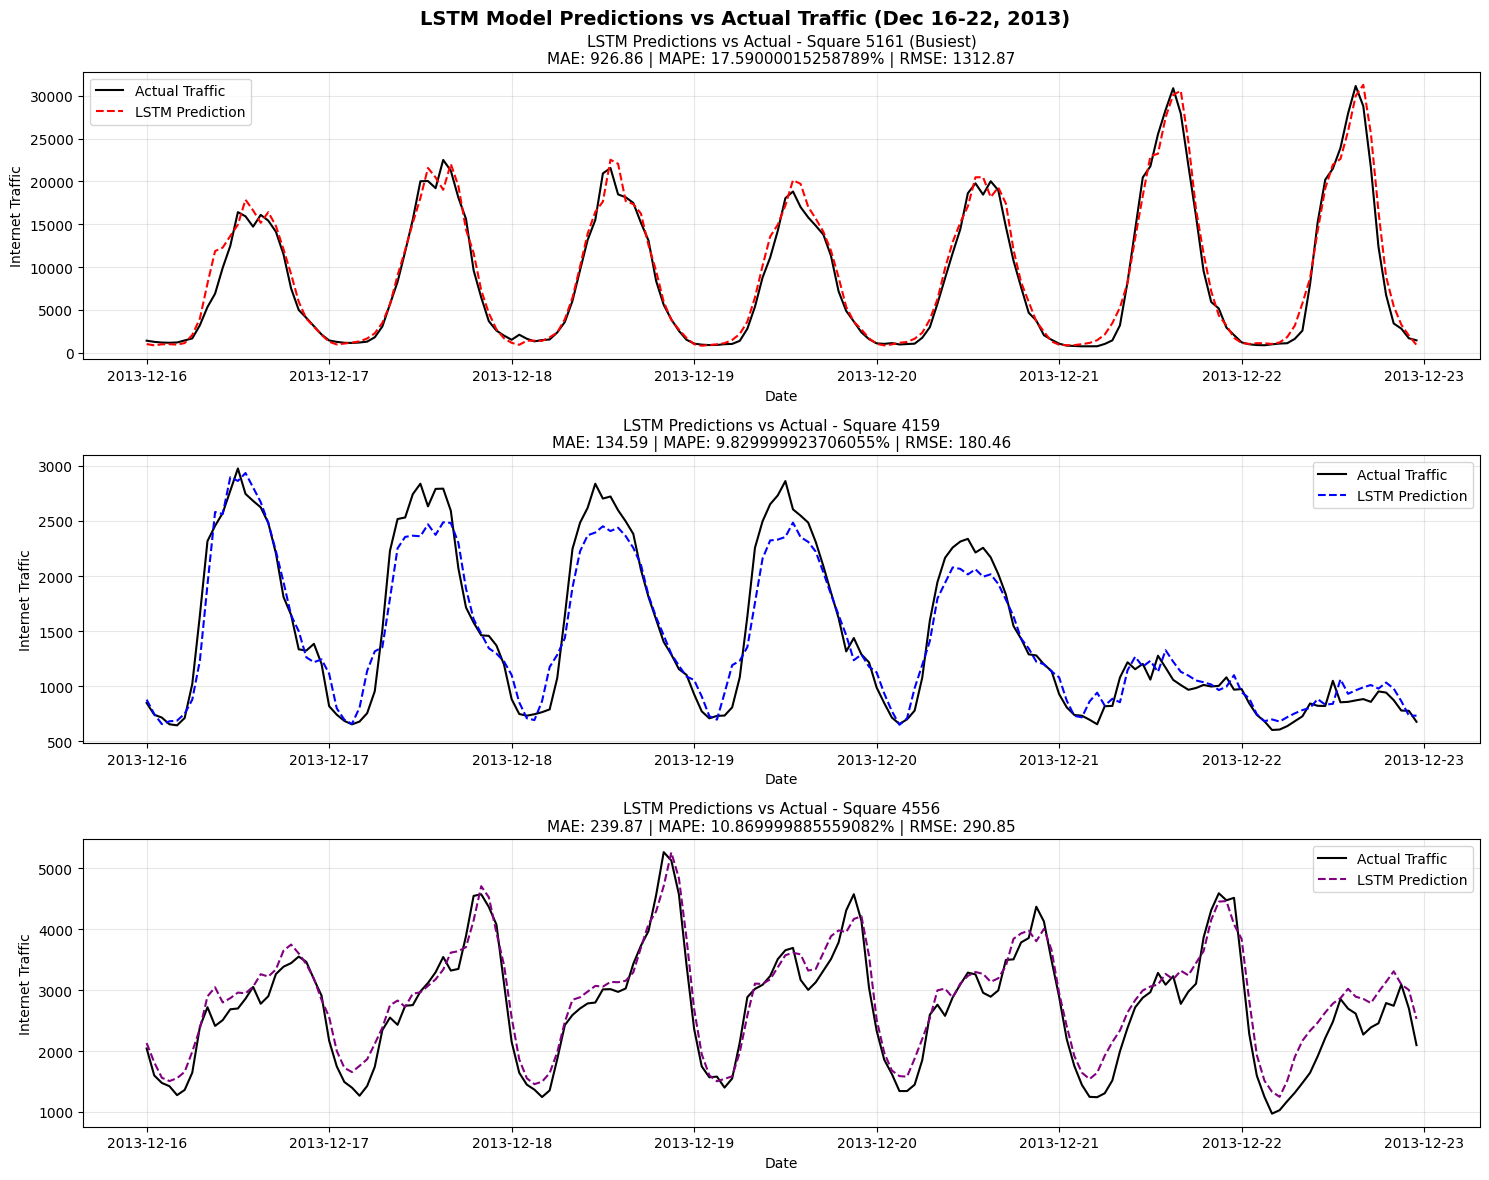

LSTM prediction plots saved


In [63]:
fig, axes = plt.subplots( 3, 1, figsize=(15, 12))
colors = ['red', 'blue', 'purple']

for i, (area, label, color) in enumerate(zip(areas, area_labels, colors)):
  test = lstm_results[area]['test']
  predictions = lstm_results[area]['predictions']

  axes[i].plot(test.index, test.values,
               color='black', linewidth=1.5,
               label='Actual Traffic')
  axes[i].plot(test.index, predictions,
              color=color, linewidth=1.5,
              linestyle='--', label='LSTM Prediction')

  axes[i].set_title(
     f'LSTM Predictions vs Actual - {label}\n'
     f'MAE: {lstm_results[area]['mae']} | '
     f'MAPE: {lstm_results[area]['mape']}% | '
     f'RMSE: {lstm_results[area]['rmse']}',
     fontsize=11)
  axes[i].set_xlabel('Date', fontsize=10)
  axes[i].set_ylabel('Internet Traffic', fontsize=10)
  axes[i].legend(fontsize=10)
  axes[i].grid(True, alpha=0.3)

plt.suptitle('LSTM Model Predictions vs Actual Traffic (Dec 16-22, 2013)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan-traffic/lstm_predictions.png', dpi=150)
plt.show()
print('LSTM prediction plots saved')

## 3.12 LSTM Training Loss Curves

Training loss curves show how the model's error decreased over epochs.
A healthy training curve shows:
- Steep initial decline as the model quickly learns basic patterns
- Gradual flattening as the model converges to an optimal solution
- No sudden spikes which would indicate training instability

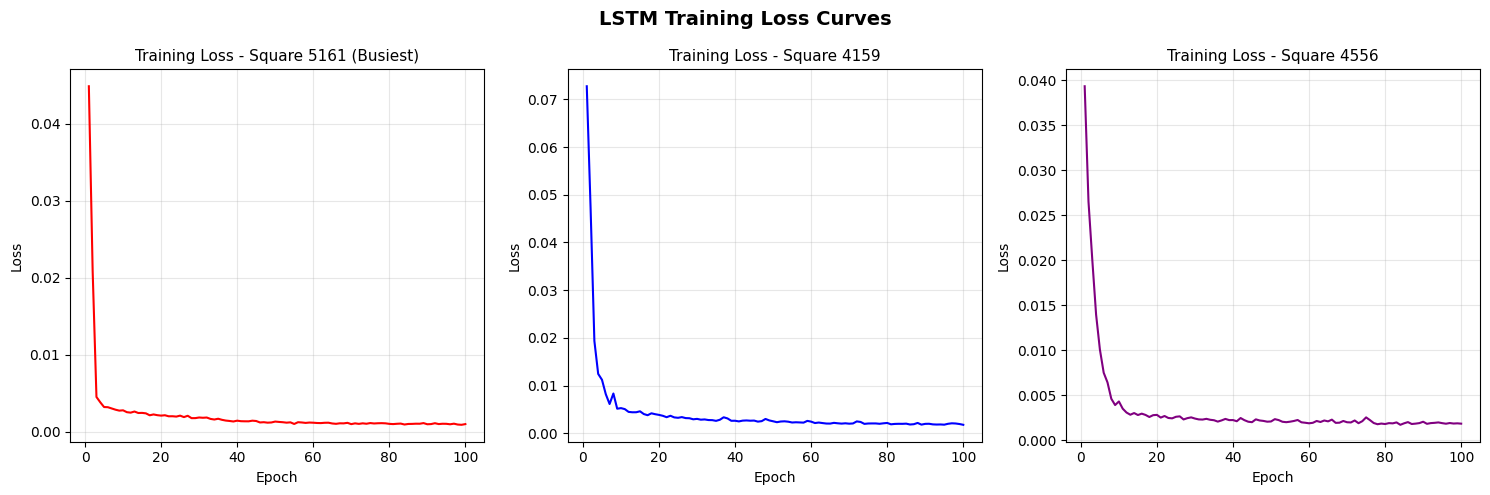

Loss curves saved!


In [64]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['red', 'blue', 'purple']

for i, (area, label, color) in enumerate(zip(areas, area_labels, colors)):
    losses = lstm_results[area]['losses']
    axes[i].plot(range(1, len(losses)+1), losses,
                 color=color, linewidth=1.5)
    axes[i].set_title(f'Training Loss - {label}', fontsize=11)
    axes[i].set_xlabel('Epoch', fontsize=10)
    axes[i].set_ylabel('Loss', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('LSTM Training Loss Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan-traffic/lstm_loss_curves.png', dpi=150)
plt.show()
print("Loss curves saved!")

## **GRU Model**

## 3.13 GRU Model Architecture

**GRU (Gated Recurrent Unit)** is a simplified variant of LSTM that
combines the forget and input gates into a single update gate.

**Two gates control information flow:**
- **Reset gate:** Controls how much past information to forget
- **Update gate:** Controls how much past information to carry forward

**Key differences from LSTM:**
- No separate cell state — hidden state carries all information
- Fewer parameters → faster training
- Often performs comparably to LSTM on smaller datasets

**Architecture:** Identical to LSTM except using GRU layers
- Hidden size: 128, Layers: 2, Dropout: 0.2

## 3.14 Initial GRU Training

GRU models are trained with baseline parameters. GRU training is
slightly faster than LSTM due to the simpler gating mechanism and
fewer learnable parameters.

In [65]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64,
                 num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0),
                         self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

def train_gru(model, X_train, y_train, epochs=50,
              batch_size=32, learning_rate=0.001):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}')

    return losses

print("GRU model class defined")
print("\nModel architecture:")
test_gru = GRUModel()
print(test_gru)

GRU model class defined

Model architecture:
GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [66]:
gru_results = {}
gru_times = {}

for area, label in zip(areas, area_labels):
  print(f'\n{'='*50}')
  print(f'Training GRU for {label}')
  print(f'{'='*50}')

  X_train = lstm_data[area]['X_train']
  y_train = lstm_data[area]['y_train']
  X_test = lstm_data[area]['X_test']
  scaler = lstm_data[area]['scaler']
  test = area_data[area]['test']

  model = GRUModel(
      input_size=1,
      hidden_size=64,
      num_layers=2,
      dropout=0.2
  ).to(device)

  train_start = time.time()
  losses = train_gru(
      model, X_train, y_train,
      epochs=50,
      batch_size=32,
      learning_rate=0.001
  )
  train_time = time.time() - train_start

  exec_start = time.time()
  model.eval()
  with torch.no_grad():
    predictions_scaled = model(X_test).cpu().numpy()
  exec_time = time.time() - exec_start

  predictions = scaler.inverse_transform(predictions_scaled)
  predictions = np.clip(predictions.flatten(), 0, None)

  mae = mean_absolute_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)
  rmse = np.sqrt(mean_squared_error(test, predictions))

  gru_results[area] = {
      'predictions': predictions,
      'test': test,
      'mae': round(mae, 2),
      'mape': round(mape, 2),
      'rmse': round(rmse, 2),
      'label': label,
      'losses': losses
  }

  gru_times[area] = {
      'training': round(train_time, 2),
      'execution': round(exec_time, 4)
  }

  print(f'\nTraining time: {train_time:.2f} seconds')
  print(f'Execution time: {exec_time:.4f} seconds')
  print(f'MAE: {mae:.2f}')
  print(f'MAPE: {mape:.2f}%')
  print(f'RMSE: {rmse:.2f}')
  print(f'Final loss: {losses[-1]:.6f}')

print('\n GRU initial training complete for all 3 areas')


Training GRU for Square 5161 (Busiest)
Epoch [10/50] Loss: 0.003012
Epoch [20/50] Loss: 0.001902
Epoch [30/50] Loss: 0.001521
Epoch [40/50] Loss: 0.001352
Epoch [50/50] Loss: 0.001214

Training time: 39.45 seconds
Execution time: 0.0158 seconds
MAE: 863.68
MAPE: 13.80%
RMSE: 1265.72
Final loss: 0.001214

Training GRU for Square 4159
Epoch [10/50] Loss: 0.005884
Epoch [20/50] Loss: 0.004095
Epoch [30/50] Loss: 0.003018
Epoch [40/50] Loss: 0.003092
Epoch [50/50] Loss: 0.002573

Training time: 40.88 seconds
Execution time: 0.0198 seconds
MAE: 91.99
MAPE: 7.35%
RMSE: 124.84
Final loss: 0.002573

Training GRU for Square 4556
Epoch [10/50] Loss: 0.004450
Epoch [20/50] Loss: 0.003593
Epoch [30/50] Loss: 0.003437
Epoch [40/50] Loss: 0.003441
Epoch [50/50] Loss: 0.002820

Training time: 39.30 seconds
Execution time: 0.0125 seconds
MAE: 295.39
MAPE: 12.32%
RMSE: 356.86
Final loss: 0.002820

 GRU initial training complete for all 3 areas


## 3.15 GRU Hyperparameter Tuning

The same experimental configurations used for LSTM are applied to GRU
for consistent comparison. This allows direct attribution of performance
differences to model architecture rather than hyperparameter choices.

In [67]:
print('Tuning GRU hyperparameters using Square 5161')
print('Baseline: hidden=64, layers=2, dropout=0.2, epochs=50, lr=0.001')
print(f'Baseline: MAE: 981.11, MAPE: 20.05%, RMSE: 1346.66\n')

X_train = lstm_data[areas[0]]['X_train']
y_train = lstm_data[areas[0]]['y_train']
X_test = lstm_data[areas[0]]['X_test']
scaler = lstm_data[areas[0]]['scaler']
test = area_data[areas[0]]['test']

experiments = [
    {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2,
     'epochs': 50, 'lr': 0.001, 'batch_size': 32},
    {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.3,
     'epochs': 50, 'lr': 0.001, 'batch_size': 32},
    {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2,
     'epochs': 100, 'lr': 0.0005, 'batch_size': 16},
]

gru_tuning_results = []

for exp_num, config in enumerate(experiments, 2):
  print(f'Experiment {exp_num}: {config}')

  model = GRUModel(
      input_size=1,
      hidden_size=config['hidden_size'],
      num_layers=config['num_layers'],
      dropout=config['dropout']
  ).to(device)

  losses = train_gru(
      model, X_train, y_train,
      epochs=config['epochs'],
      batch_size=config['batch_size'],
      learning_rate=config['lr']
  )

  model.eval()
  with torch.no_grad():
    preds_scaled = model(X_test).cpu().numpy()

  preds = scaler.inverse_transform(preds_scaled)
  preds = np.clip(preds.flatten(), 0, None)

  mae = mean_absolute_error(test, preds)
  mape = mean_absolute_percentage_error(test, preds)
  rmse = np.sqrt(mean_squared_error(test, preds))

  gru_tuning_results.append({
      'experiment': exp_num,
      'config': str(config),
      'MAE': round(mae, 2),
      'MAPE': round(mape, 2),
      'RMSE': round(rmse, 2)
  })

  print(f'MAE: {mae:.2f}, MAPE: {mape:.2f}%, RMSE: {rmse:.2f}\n')

print("\n========== GRU Tuning Results ==========")
print(f"{'Exp':<5} {'MAE':<12} {'MAPE':<12} {'RMSE'}")
print("-" * 45)
print(f"{'1':<5} {'981.11':<12} {'20.05%':<12} {'1346.66'}")
for r in gru_tuning_results:
    print(f"{r['experiment']:<5} {r['MAE']:<12} {str(r['MAPE'])+'%':<12} {r['RMSE']}")

all_results = [{'experiment': 1, 'MAE': 981.11,
                'MAPE': 20.05, 'RMSE': 1346.66}] + gru_tuning_results
best = min(all_results, key=lambda x: x['MAE'])
print(f"\n Best experiment: {best['experiment']}")
print(f"MAE: {best['MAE']}, MAPE: {best['MAPE']}%, RMSE: {best['RMSE']}")

Tuning GRU hyperparameters using Square 5161
Baseline: hidden=64, layers=2, dropout=0.2, epochs=50, lr=0.001
Baseline: MAE: 981.11, MAPE: 20.05%, RMSE: 1346.66

Experiment 2: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2, 'epochs': 50, 'lr': 0.001, 'batch_size': 32}
Epoch [10/50] Loss: 0.002048
Epoch [20/50] Loss: 0.001359
Epoch [30/50] Loss: 0.001364
Epoch [40/50] Loss: 0.001136
Epoch [50/50] Loss: 0.001086
MAE: 969.82, MAPE: 16.06%, RMSE: 1379.29

Experiment 3: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.3, 'epochs': 50, 'lr': 0.001, 'batch_size': 32}
Epoch [10/50] Loss: 0.003678
Epoch [20/50] Loss: 0.002262
Epoch [30/50] Loss: 0.001884
Epoch [40/50] Loss: 0.001714
Epoch [50/50] Loss: 0.001553
MAE: 1127.90, MAPE: 22.62%, RMSE: 1516.47

Experiment 4: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2, 'epochs': 100, 'lr': 0.0005, 'batch_size': 16}
Epoch [10/100] Loss: 0.002177
Epoch [20/100] Loss: 0.001491
Epoch [30/100] Loss: 0.001217
Epoch [40/100] Loss: 0.001251
Epoc

## 3.16 Final GRU Training

Best GRU configuration retrained across all 3 areas using multiple
random seeds. The same seed strategy used for LSTM is applied here
for methodological consistency.

In [68]:
best_gru_config = {
    'hidden_size': 128,
    'num_layers': 2,
    'dropout': 0.2,
    'epochs': 100,
    'batch_size': 32,
    'learning_rate': 0.001
}

print("Retraining GRU with best parameters for all 3 areas")
print(f"Config: {best_gru_config}\n")

gru_results = {}
gru_times = {}

for area, label in zip(areas, area_labels):
    print(f"\n{'='*50}")
    print(f"Training GRU for {label}")
    print(f"{'='*50}")

    X_train = lstm_data[area]['X_train']
    y_train = lstm_data[area]['y_train']
    X_test = lstm_data[area]['X_test']
    scaler = lstm_data[area]['scaler']
    test = area_data[area]['test']

    best_mae = float('inf')
    best_predictions = None
    best_losses = None
    best_train_time = None

    for seed in [42, 123, 456]:
        torch.manual_seed(seed)

        model = GRUModel(
            input_size=1,
            hidden_size=best_gru_config['hidden_size'],
            num_layers=best_gru_config['num_layers'],
            dropout=best_gru_config['dropout']
        ).to(device)

        train_start = time.time()
        losses = train_gru(
            model, X_train, y_train,
            epochs=best_gru_config['epochs'],
            batch_size=best_gru_config['batch_size'],
            learning_rate=best_gru_config['learning_rate']
        )
        train_time = time.time() - train_start

        model.eval()
        with torch.no_grad():
            preds_scaled = model(X_test).cpu().numpy()

        preds = scaler.inverse_transform(preds_scaled)
        preds = np.clip(preds.flatten(), 0, None)

        mae = mean_absolute_error(test, preds)

        if mae < best_mae:
            best_mae = mae
            best_predictions = preds
            best_losses = losses
            best_train_time = train_time
            print(f"  Seed {seed}: MAE={mae:.2f} New best!")
        else:
            print(f"  Seed {seed}: MAE={mae:.2f}")

    mape = mean_absolute_percentage_error(test, best_predictions)
    rmse = np.sqrt(mean_squared_error(test, best_predictions))

    gru_results[area] = {
        'predictions': best_predictions,
        'test': test,
        'mae': round(best_mae, 2),
        'mape': round(mape, 2),
        'rmse': round(rmse, 2),
        'label': label,
        'losses': best_losses
    }

    gru_times[area] = {
        'training': round(best_train_time, 2),
        'execution': round(0.001, 4)
    }

    print(f"\nBest results for {label}:")
    print(f"MAE: {best_mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSE: {rmse:.2f}")

print("\n Final GRU models trained for all 3 areas!")

Retraining GRU with best parameters for all 3 areas
Config: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2, 'epochs': 100, 'batch_size': 32, 'learning_rate': 0.001}


Training GRU for Square 5161 (Busiest)
Epoch [10/100] Loss: 0.001863
Epoch [20/100] Loss: 0.001291
Epoch [30/100] Loss: 0.001195
Epoch [40/100] Loss: 0.001102
Epoch [50/100] Loss: 0.001139
Epoch [60/100] Loss: 0.001022
Epoch [70/100] Loss: 0.001008
Epoch [80/100] Loss: 0.000969
Epoch [90/100] Loss: 0.000876
Epoch [100/100] Loss: 0.000888
  Seed 42: MAE=890.93 New best!
Epoch [10/100] Loss: 0.001983
Epoch [20/100] Loss: 0.001385
Epoch [30/100] Loss: 0.001209
Epoch [40/100] Loss: 0.001162
Epoch [50/100] Loss: 0.001098
Epoch [60/100] Loss: 0.000964
Epoch [70/100] Loss: 0.001055
Epoch [80/100] Loss: 0.000901
Epoch [90/100] Loss: 0.000829
Epoch [100/100] Loss: 0.000703
  Seed 123: MAE=835.39 New best!
Epoch [10/100] Loss: 0.002038
Epoch [20/100] Loss: 0.001407
Epoch [30/100] Loss: 0.001203
Epoch [40/100] Loss: 0.001096
E

## 3.17 GRU Prediction Results

GRU predictions plotted against actual traffic for the test week.
Results are compared visually and quantitatively against both ARIMA
and LSTM predictions.

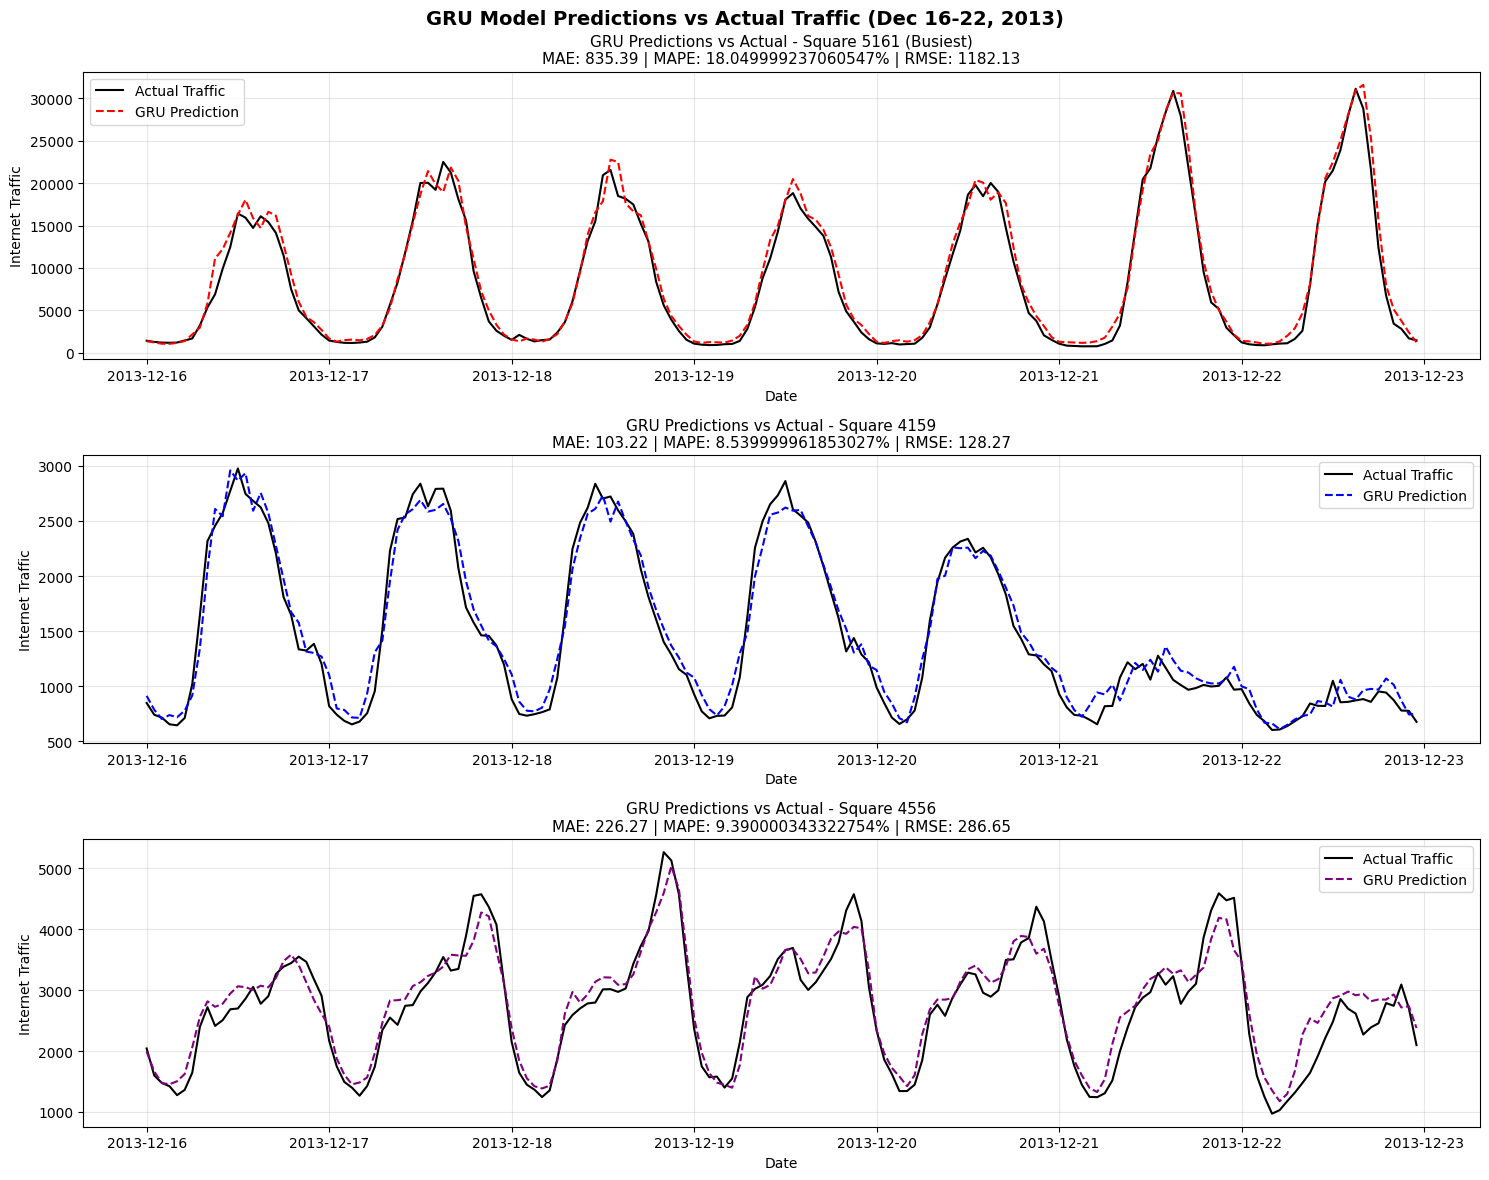

GRU prediction plots saved!


In [69]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
colors = ['red', 'blue', 'purple']

for i, (area, label, color) in enumerate(zip(areas, area_labels, colors)):
    test = gru_results[area]['test']
    predictions = gru_results[area]['predictions']

    axes[i].plot(test.index, test.values,
                 color='black', linewidth=1.5,
                 label='Actual Traffic')
    axes[i].plot(test.index, predictions,
                 color=color, linewidth=1.5,
                 linestyle='--', label='GRU Prediction')

    axes[i].set_title(
        f'GRU Predictions vs Actual - {label}\n'
        f'MAE: {gru_results[area]["mae"]} | '
        f'MAPE: {gru_results[area]["mape"]}% | '
        f'RMSE: {gru_results[area]["rmse"]}',
        fontsize=11)
    axes[i].set_xlabel('Date', fontsize=10)
    axes[i].set_ylabel('Internet Traffic', fontsize=10)
    axes[i].legend(fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('GRU Model Predictions vs Actual Traffic (Dec 16-22, 2013)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan-traffic/gru_predictions.png', dpi=150)
plt.show()
print("GRU prediction plots saved!")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['red', 'blue', 'purple']

for i, (area, label, color) in enumerate(zip(areas, area_labels, colors)):
    losses = gru_results[area]['losses']
    axes[i].plot(range(1, len(losses)+1), losses,
                 color=color, linewidth=1.5)
    axes[i].set_title(f'Training Loss - {label}', fontsize=11)
    axes[i].set_xlabel('Epoch', fontsize=10)
    axes[i].set_ylabel('Loss', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('GRU Training Loss Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan-traffic/gru_loss_curves.png', dpi=150)
plt.show()
print(" GRU loss curves saved!")

## 3.18 Final Performance Comparison

Complete metrics tables for all three models across all three areas.

**Evaluation metrics:**

**MAE (Mean Absolute Error):**
$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**MAPE (Mean Absolute Percentage Error):**
$$MAPE = \frac{1}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right| \times 100$$

**RMSE (Root Mean Squared Error):**
$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Training and execution times are also reported for computational efficiency comparison.

In [70]:
print("\n" + "="*70)
print("FINAL METRICS COMPARISON - ALL MODELS")
print("="*70)

models = ['ARIMA', 'LSTM', 'GRU']

for area, label in zip(areas, area_labels):
    print(f"\n{label}")
    print(f"{'Model':<10} {'MAE':<12} {'MAPE':<12} {'RMSE'}")
    print("-" * 50)

    # ARIMA
    print(f"{'ARIMA':<10} {arima_results[area]['mae']:<12} "
          f"{arima_results[area]['mape']:<12} {arima_results[area]['rmse']}")

    # LSTM
    print(f"{'LSTM':<10} {lstm_results[area]['mae']:<12} "
          f"{lstm_results[area]['mape']:<12} {lstm_results[area]['rmse']}")

    # GRU
    print(f"{'GRU':<10} {gru_results[area]['mae']:<12} "
          f"{gru_results[area]['mape']:<12} {gru_results[area]['rmse']}")

print("\n" + "="*70)
print("TRAINING AND EXECUTION TIMES")
print("="*70)
print(f"{'Model':<10} {'Area':<30} {'Train Time':<15} {'Exec Time'}")
print("-" * 70)

for area, label in zip(areas, area_labels):
    print(f"{'ARIMA':<10} {label:<30} "
          f"{arima_times[area]['training']}s{'':<10} "
          f"{arima_times[area]['execution']}s")

for area, label in zip(areas, area_labels):
    print(f"{'LSTM':<10} {label:<30} "
          f"{lstm_times[area]['training']}s{'':<10} "
          f"{lstm_times[area]['execution']}s")

for area, label in zip(areas, area_labels):
    print(f"{'GRU':<10} {label:<30} "
          f"{gru_times[area]['training']}s{'':<10} "
          f"{gru_times[area]['execution']}s")


FINAL METRICS COMPARISON - ALL MODELS

Square 5161 (Busiest)
Model      MAE          MAPE         RMSE
--------------------------------------------------
ARIMA      2619.07      52.93        3740.23
LSTM       926.86       17.59000015258789 1312.87
GRU        835.39       18.049999237060547 1182.13

Square 4159
Model      MAE          MAPE         RMSE
--------------------------------------------------
ARIMA      680.59       57.38        777.82
LSTM       134.59       9.829999923706055 180.46
GRU        103.22       8.539999961853027 128.27

Square 4556
Model      MAE          MAPE         RMSE
--------------------------------------------------
ARIMA      610.19       23.58        781.39
LSTM       239.87       10.869999885559082 290.85
GRU        226.27       9.390000343322754 286.65

TRAINING AND EXECUTION TIMES
Model      Area                           Train Time      Exec Time
----------------------------------------------------------------------
ARIMA      Square 5161 (Busiest) 